### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import math
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

### Load the data

In [2]:
df = pd.read_csv("../data/processed/ridewise_eda_data.csv")

In [3]:
df.head()

,customer_id,first_name,last_name,email,phone,city,signup_date,age,gender,total_trips,...,promo_used_count,total_promo_cost,avg_promo_cost,avg_discount_value,avg_driver_burden,driver_borne_total,discount_total_fixed,driver_burden_ratio,platform_burden_ratio,promo_used_rate
0,CUST00000,Adrian,Walker,adrian.walker@gmail.com,020 7946 0251,London,2024-04-27,19,Other,63,...,6.0,63.76,10.626667,11.586667,0.960000,2.09,65.85,0.031739,0.968261,0.095238
1,CUST00001,Tony,Jones,tony.jones@hotmail.co.uk,+441164960985,London,2023-10-01,61,Other,52,...,6.0,66.15,11.025000,14.035000,3.010000,0.42,66.57,0.006309,0.993691,0.115385
2,CUST00002,Lynn,Carter,lynn.carter@outlook.com,+44(0)20 7496 0628,London,2025-01-22,31,Male,47,...,8.0,57.60,7.200000,9.818750,2.618750,3.57,61.17,0.058362,0.941638,0.170213
3,CUST00003,Marcelo,Madrigal,marcelo.madrigal@hotmail.com,+34987 210 730,Barcelona,2025-03-01,55,Female,44,...,7.0,99.69,14.241429,18.787143,4.545714,3.62,103.31,0.035040,0.964960,0.159091
4,CUST00004,Faye,Strik,faye.strik@hotmail.com,086 1284110,Amsterdam,2025-09-13,27,Male,30,...,3.0,33.38,11.126667,12.253333,1.126667,3.92,37.30,0.105094,0.894906,0.100000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              3000 non-null   object 
 1   first_name               3000 non-null   object 
 2   last_name                3000 non-null   object 
 3   email                    3000 non-null   object 
 4   phone                    3000 non-null   object 
 5   city                     3000 non-null   object 
 6   signup_date              3000 non-null   object 
 7   age                      3000 non-null   int64  
 8   gender                   3000 non-null   object 
 9   total_trips              3000 non-null   int64  
 10  cancelled_trips          3000 non-null   int64  
 11  days_since_last_trip     3000 non-null   int64  
 12  churned                  3000 non-null   int64  
 13  engagement_score         3000 non-null   float64
 14  loyalty_score           

In [5]:
# Check for duplicates
df.duplicated().sum()

0

In [6]:
# Check for missing values

df.isna().sum()

customer_id                0
first_name                 0
last_name                  0
email                      0
phone                      0
city                       0
signup_date                0
age                        0
gender                     0
total_trips                0
cancelled_trips            0
days_since_last_trip       0
churned                    0
engagement_score           0
loyalty_score              0
persona                    0
signup_channel             0
income_level               0
payment_method             0
device_type                0
age_band                   0
app_open_events            0
search_events              0
ride_request_events        0
ride_completed_events      0
ride_conversion_rate       0
request_to_search_ratio    0
search_to_open_ratio       0
last_event_date            0
active_days                0
total_completed_trips      0
total_cancelled_trips      0
total_gross_revenue        0
avg_gross_revenue          0
net_platform_r

<Axes: >

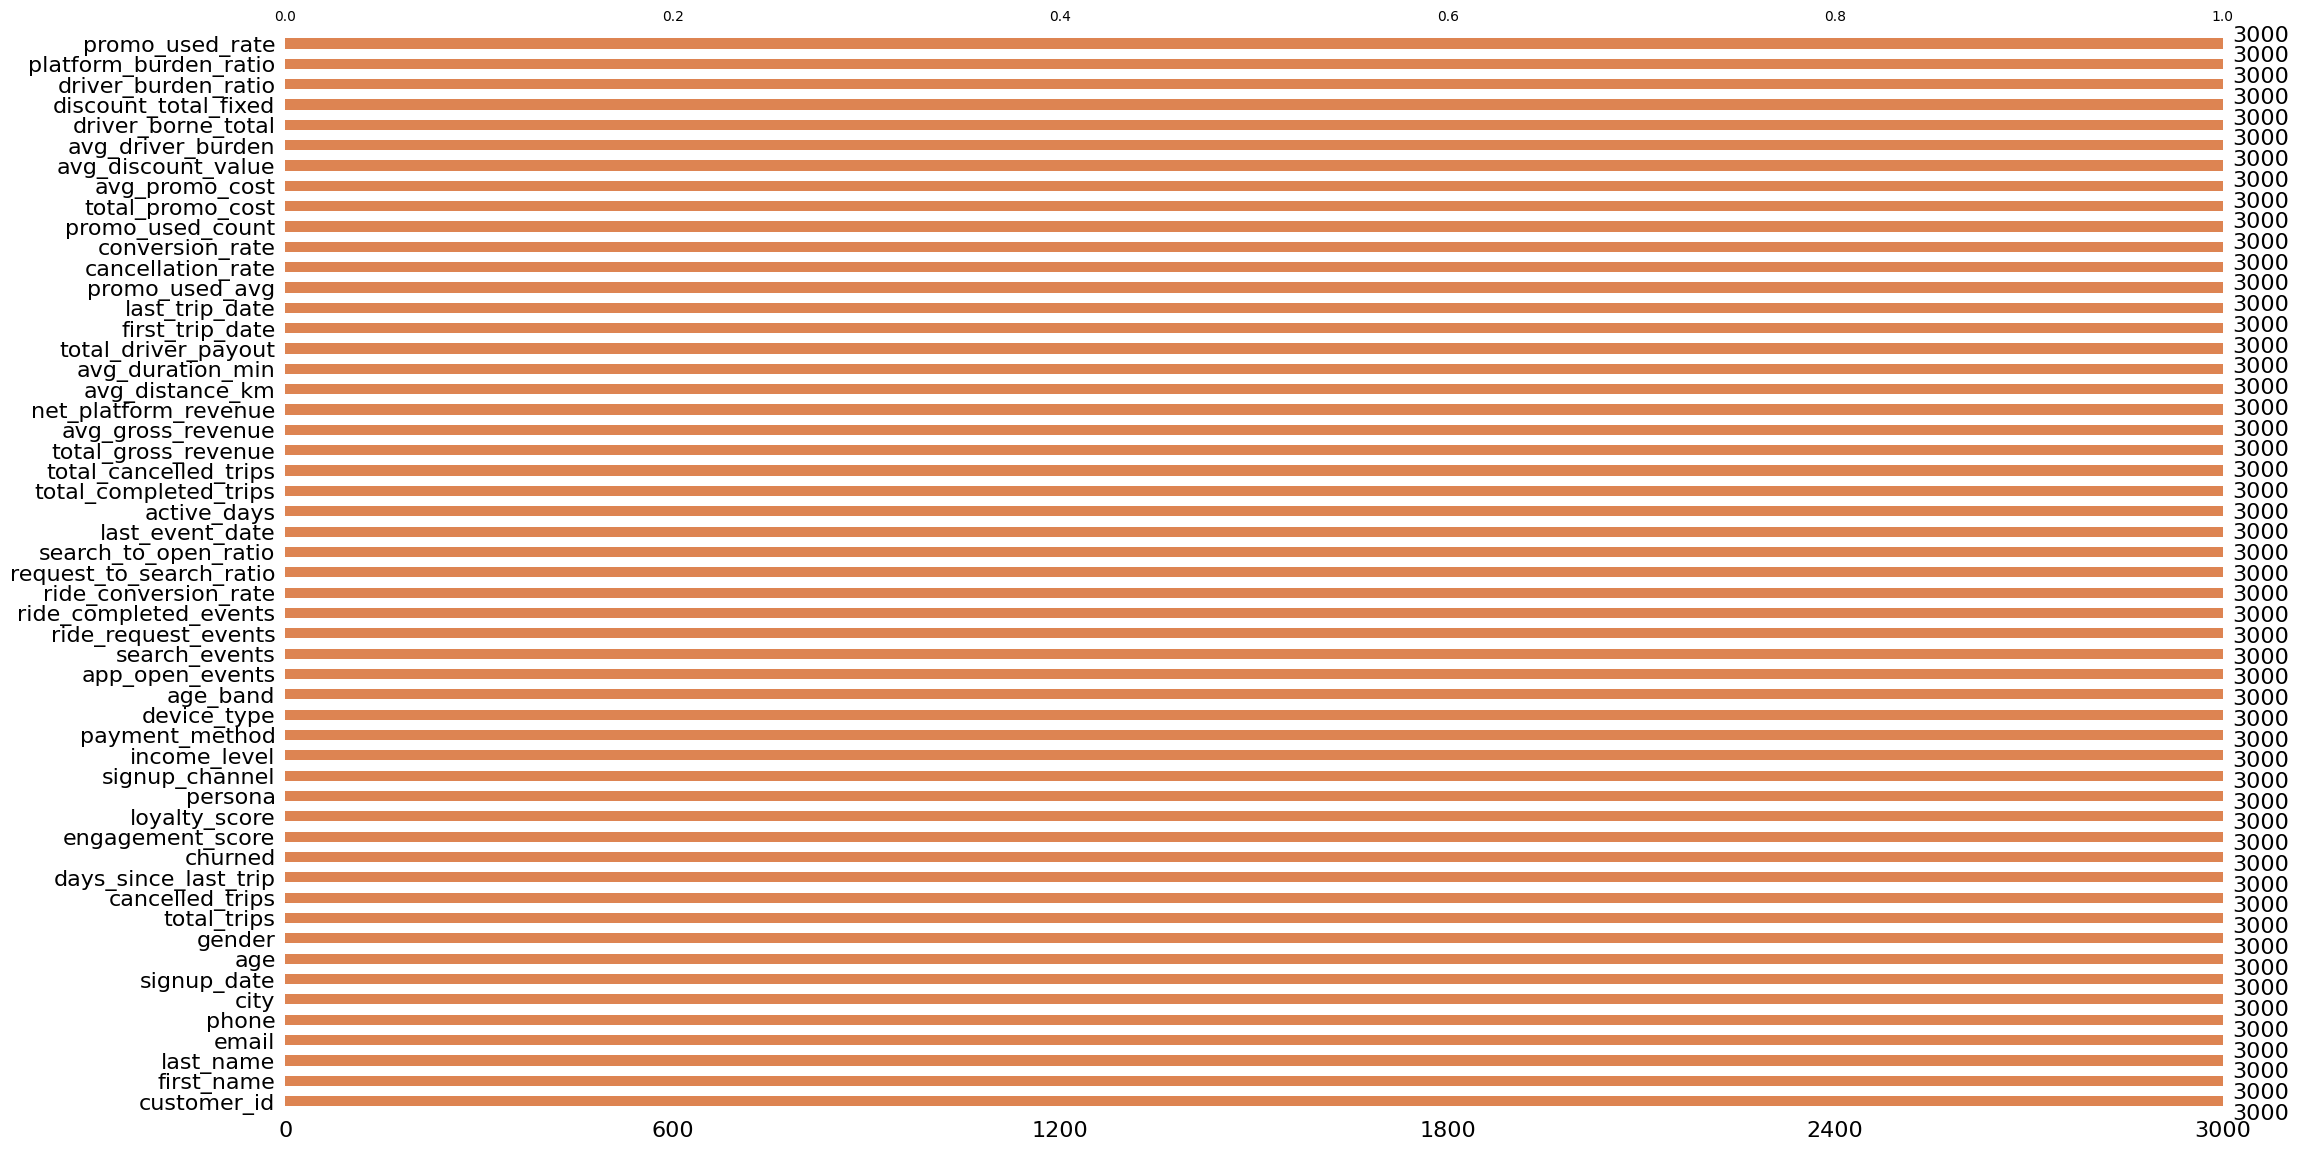

In [7]:
# Graphically represent missing values

msno.bar(df, color="#DD8452")

In [8]:
# Reconfirm missing values
df.isnull().sum()

customer_id                0
first_name                 0
last_name                  0
email                      0
phone                      0
city                       0
signup_date                0
age                        0
gender                     0
total_trips                0
cancelled_trips            0
days_since_last_trip       0
churned                    0
engagement_score           0
loyalty_score              0
persona                    0
signup_channel             0
income_level               0
payment_method             0
device_type                0
age_band                   0
app_open_events            0
search_events              0
ride_request_events        0
ride_completed_events      0
ride_conversion_rate       0
request_to_search_ratio    0
search_to_open_ratio       0
last_event_date            0
active_days                0
total_completed_trips      0
total_cancelled_trips      0
total_gross_revenue        0
avg_gross_revenue          0
net_platform_r

### Data Sanity Checks

In [9]:
# Duplicate customer check
df['customer_id'].is_unique

True

In [10]:
# Churn validity check
df['churned'].value_counts()

churned
0    2451
1     549
Name: count, dtype: int64

In [11]:
# Cancellation logic consistency
(df['cancelled_trips'] <= df['total_trips']).all()

True

In [12]:
# Time logic checks
(df['days_since_last_trip'] >= 0).all()

True

In [13]:
(df['first_trip_date'] <= df['last_trip_date']).all()

True

In [14]:
# Check ratios for Nan
ratio_cols = [
    'ride_conversion_rate', 'request_to_search_ratio', 'search_to_open_ratio', 'conversion_rate',
    'cancellation_rate', 'driver_burden_ratio', 'platform_burden_ratio', 'promo_used_rate']

df[ratio_cols].isna().sum()

ride_conversion_rate       0
request_to_search_ratio    0
search_to_open_ratio       0
conversion_rate            0
cancellation_rate          0
driver_burden_ratio        0
platform_burden_ratio      0
promo_used_rate            0
dtype: int64

### Observation of Findings
All engineered ratio features were validated for missing values and division errors. No NaNs were detected across conversion, cancellation, promotion, or cost-burden ratios, confirming stable denominator handling and data integrity.

In [15]:
df[ratio_cols].describe()

,ride_conversion_rate,request_to_search_ratio,search_to_open_ratio,conversion_rate,cancellation_rate,driver_burden_ratio,platform_burden_ratio,promo_used_rate
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.739026,0.587506,0.603022,0.874056,0.125944,0.080714,0.880619,0.090197
std,0.222706,0.121417,0.061808,0.061231,0.061231,0.105717,0.205222,0.050254
min,0.142857,0.241379,0.342857,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.593750,0.500000,0.561905,0.838710,0.085106,0.007563,0.874476,0.057143
50%,0.714286,0.580000,0.603774,0.880000,0.120000,0.044945,0.946683,0.086957
75%,0.848864,0.660714,0.642857,0.914894,0.161290,0.109276,0.987504,0.116279
max,2.285714,1.357143,0.838710,1.000000,1.000000,0.816485,1.000000,1.000000


### Observation of Findings
Although no missing values were detected in ratio features, distribution analysis revealed structurally invalid values (ratios exceeding 1 and negative cost ratios), indicating remaining aggregation or denominator-alignment issues. These were flagged for correction prior to EDA.

In [16]:
# drop ratio features with invalid values
df = df.drop(columns=['request_to_search_ratio', 'ride_conversion_rate'], errors='ignore')

In [17]:
# Statistical overview
df.describe()

,age,total_trips,cancelled_trips,days_since_last_trip,churned,engagement_score,loyalty_score,app_open_events,search_events,ride_request_events,...,promo_used_count,total_promo_cost,avg_promo_cost,avg_discount_value,avg_driver_burden,driver_borne_total,discount_total_fixed,driver_burden_ratio,platform_burden_ratio,promo_used_rate
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,42.905333,42.234333,3.104333,21.240667,0.183000,0.999298,0.858423,73.528667,44.331000,25.741333,...,3.798000,43.066403,10.903065,13.582644,2.679579,2.779193,45.845597,0.080714,0.880619,0.090197
std,14.851012,15.095387,2.495634,21.798298,0.386731,0.006107,0.084453,26.523103,16.544647,10.096785,...,2.273086,28.556397,4.149331,4.798066,1.871172,2.815159,28.852261,0.105717,0.205222,0.050254
min,18.000000,1.000000,0.000000,0.000000,0.000000,0.893000,0.566000,30.000000,12.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,-2.150000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,32.000000,1.000000,6.000000,0.000000,1.000000,0.800000,49.750000,30.000000,17.000000,...,2.000000,22.080000,8.867500,11.586667,1.390000,0.357500,25.015000,0.007563,0.874476,0.057143
50%,43.000000,41.000000,3.000000,15.000000,0.000000,1.000000,0.856000,74.000000,44.000000,26.000000,...,4.000000,38.755000,11.002500,13.749286,2.551250,1.975000,41.820000,0.044945,0.946683,0.086957
75%,56.000000,51.000000,5.000000,30.000000,0.000000,1.000000,0.919000,96.000000,58.000000,34.000000,...,5.000000,59.237500,13.145083,16.096250,3.801875,4.470000,62.112500,0.109276,0.987504,0.116279
max,68.000000,118.000000,17.000000,167.000000,1.000000,1.000000,1.000000,120.000000,87.000000,52.000000,...,14.000000,194.500000,28.510000,30.000000,13.830000,14.630000,199.580000,0.816485,1.000000,1.000000


### Check for Outliers

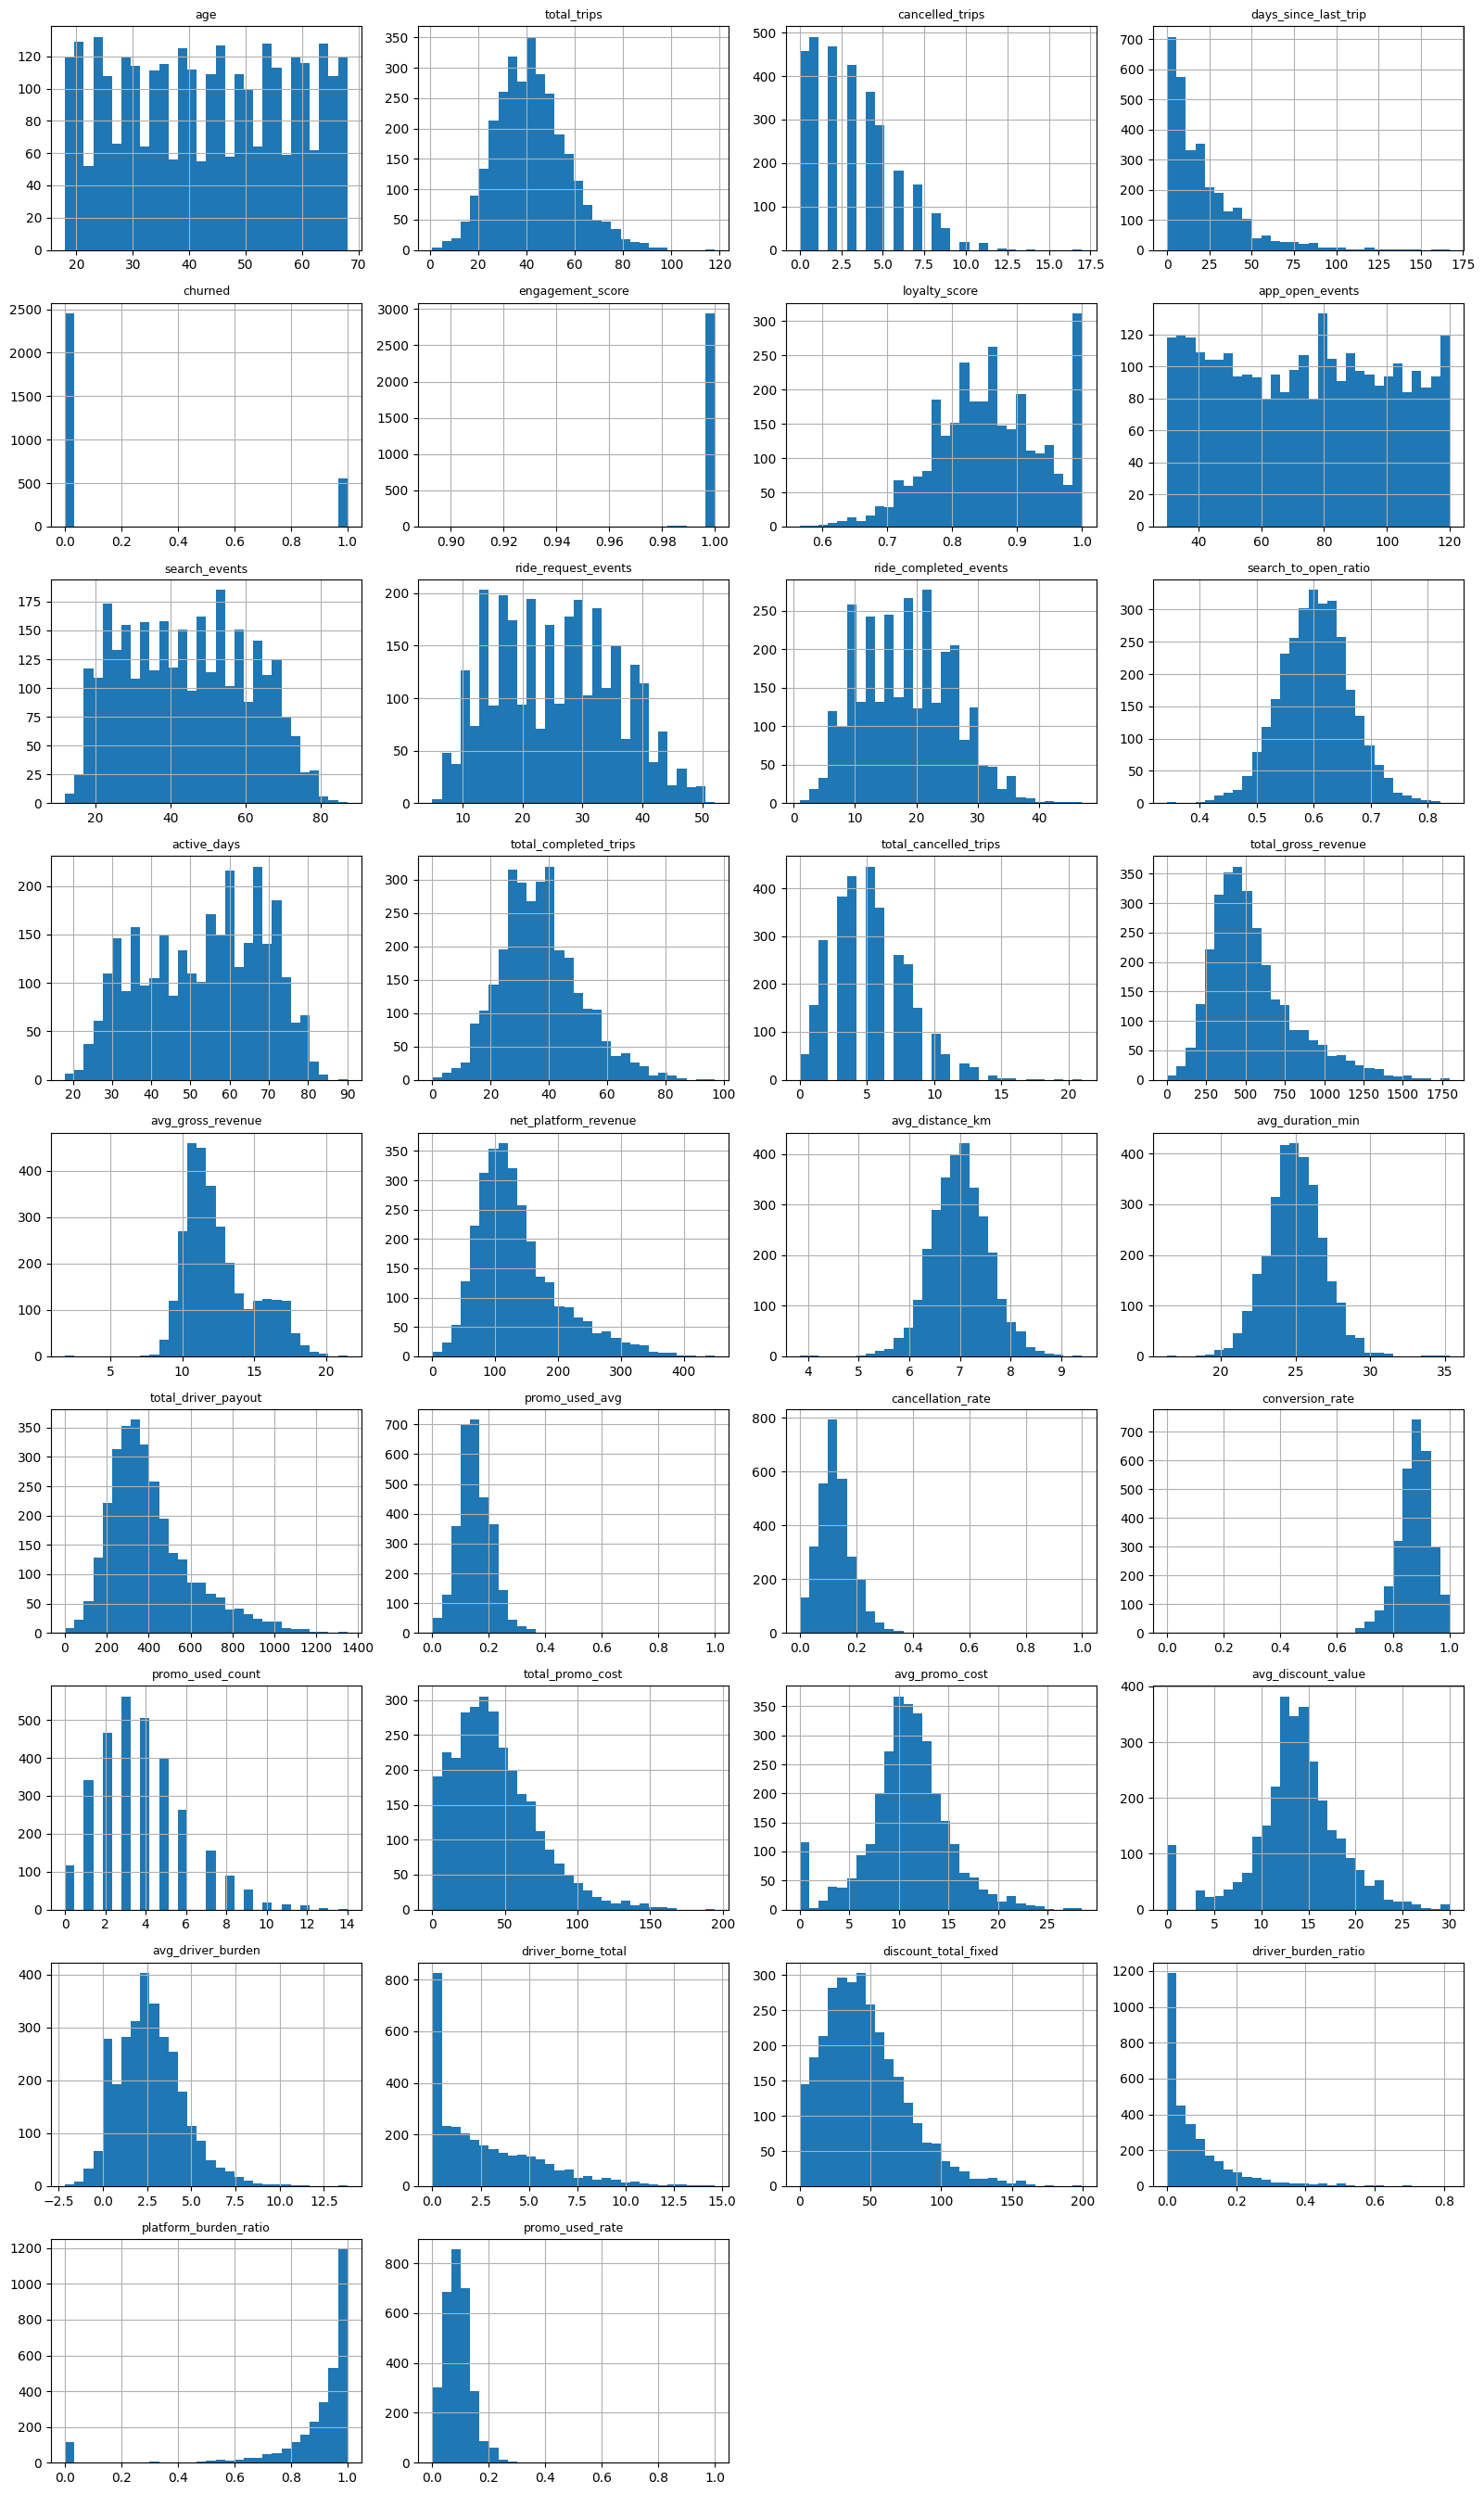

In [18]:
# Distribution Plot
num_cols = df.select_dtypes(include='number').columns.tolist()

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(True)

# Turn off unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Observation of Findings
Distribution analysis revealed strong right-skew in revenue, engagement, and promotion features, consistent with heterogeneous customer behavior and power-user dynamics.

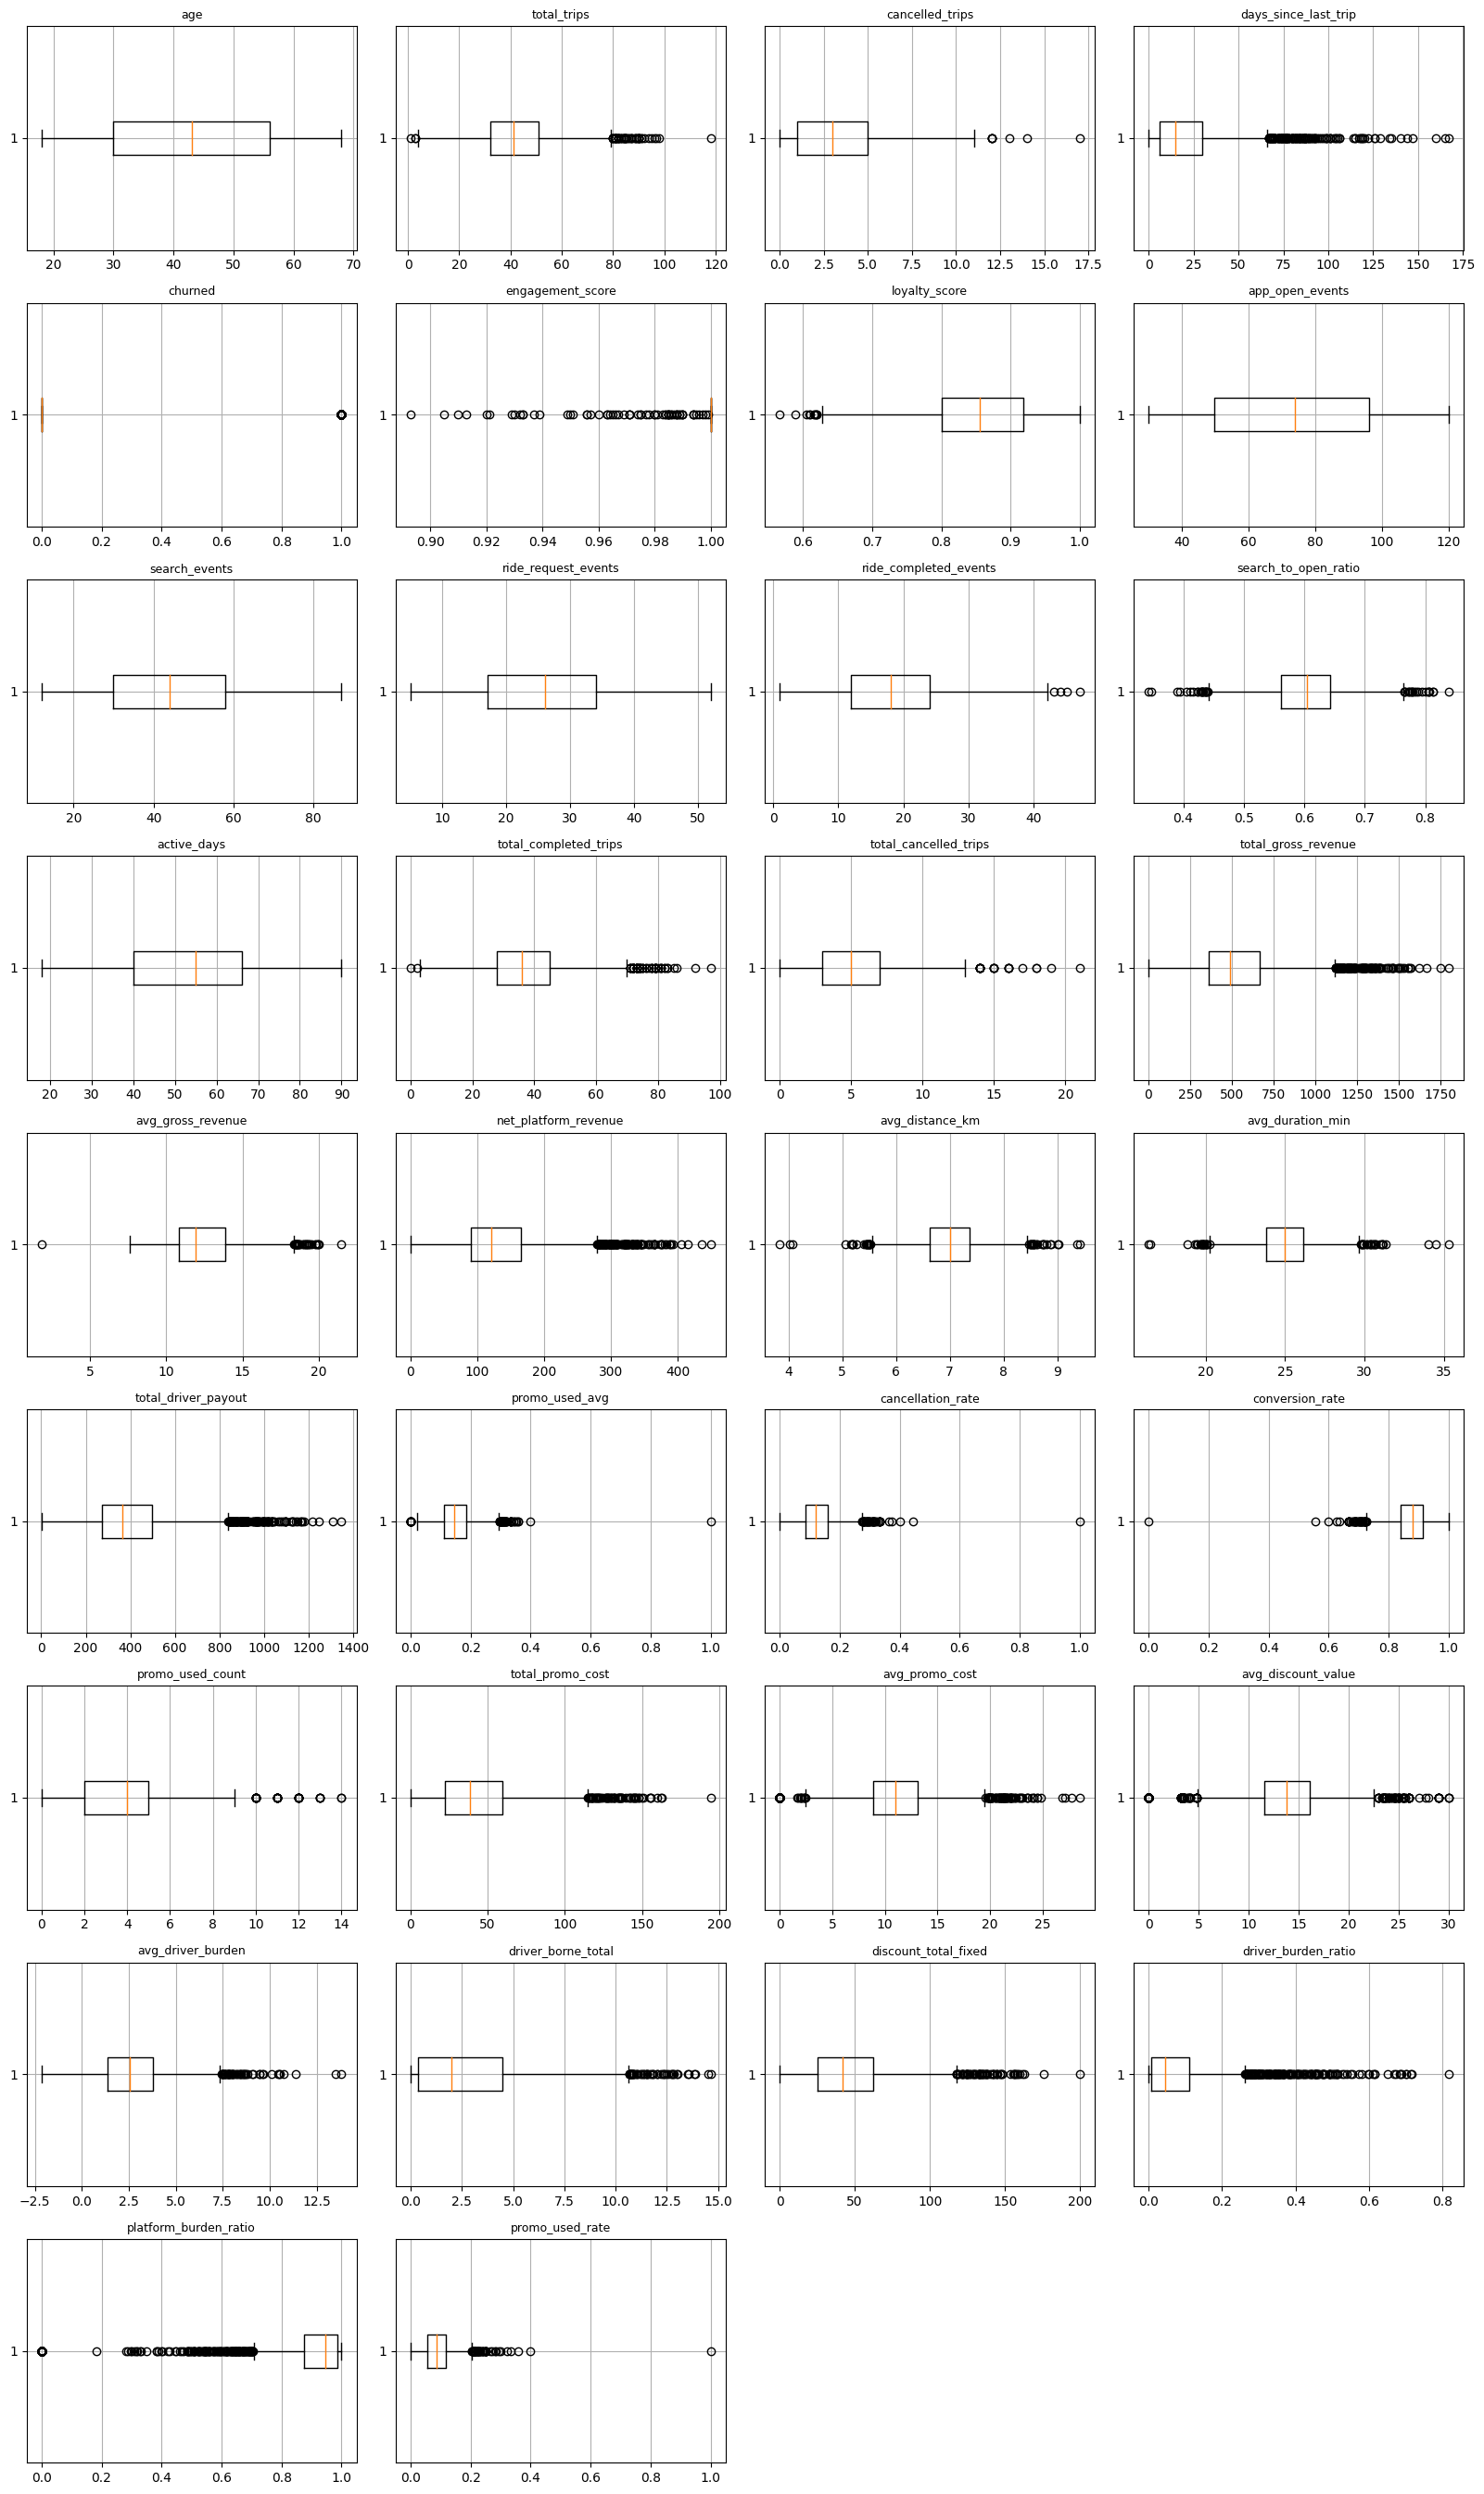

In [19]:
num_cols = df.select_dtypes(include='number').columns.tolist()

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(True)

# Turn off empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### Observation of Findings
Boxplot analysis indicates the presence of structural outliers driven by highly active and high-value customers rather than data errors. Ratio and rate features remain within logical bounds, confirming metric integrity

### Data Exploration

In [20]:
# To display float in 2 decimal places

pd.options.display.float_format = "{:.3f}".format

In [21]:
# Cancellation rate vs churn
cancel = df.groupby(pd.qcut(df['cancellation_rate'], 4))['churned'].mean().sort_values(ascending=False)

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\562322278.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel = df.groupby(pd.qcut(df['cancellation_rate'], 4))['churned'].mean().sort_values(ascending=False)


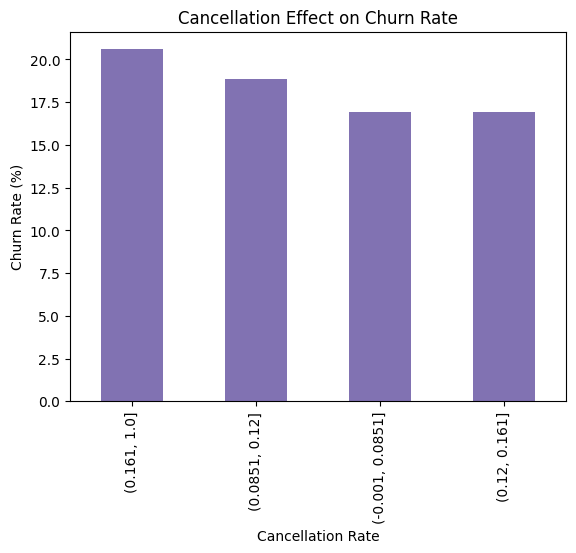

cancellation_rate
(0.161, 1.0]       0.206
(0.0851, 0.12]     0.189
(-0.001, 0.0851]   0.169
(0.12, 0.161]      0.169
Name: churned, dtype: float64

In [22]:
(cancel * 100).plot(kind='bar', color='#8172B2')
plt.title('Cancellation Effect on Churn Rate')
plt.ylabel('Churn Rate (%)')
plt.xlabel("Cancellation Rate")

plt.show()

cancel

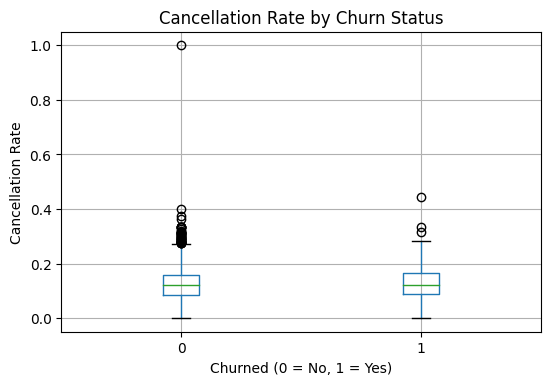

In [23]:
df.boxplot(
    column='cancellation_rate',
    by='churned',
    figsize=(6,4)
)
plt.title('Cancellation Rate by Churn Status')
plt.suptitle('')
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Cancellation Rate')
plt.show()


### Observation of Findings
Cancellation rate shows a modest association with churn: churn varies from ~16.5% to ~19.6% across cancellation-rate quartiles (3.1% spread). However, the churned vs non-churned boxplots overlap heavily, indicating cancellation rate contribute to customer dissatisfaction and increase the likelihood of churn, but not a strong separator making it a behaviorally meaningful churn driver.

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\1555350445.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conv = df.groupby(pd.qcut(df['conversion_rate'], 4))['churned'].mean().sort_values(ascending=False)


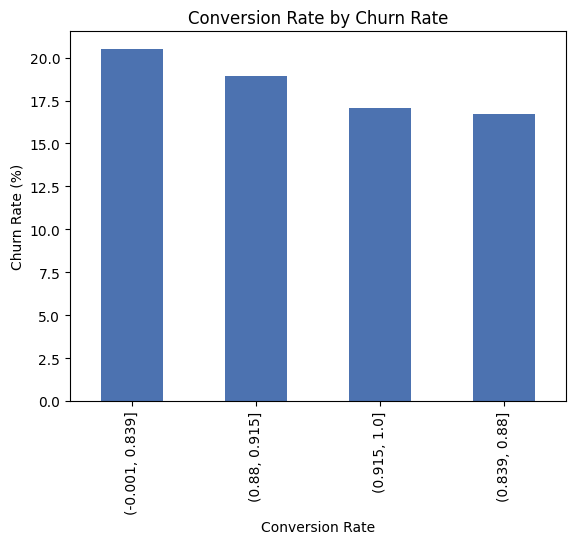

conversion_rate
(-0.001, 0.839]   0.205
(0.88, 0.915]     0.189
(0.915, 1.0]      0.171
(0.839, 0.88]     0.167
Name: churned, dtype: float64

In [24]:
# Conversion rate vs churn
conv = df.groupby(pd.qcut(df['conversion_rate'], 4))['churned'].mean().sort_values(ascending=False)

(conv * 100).plot(kind='bar', color='#4C72B0')
plt.title('Conversion Rate by Churn Rate')
plt.ylabel('Churn Rate (%)')
plt.xlabel("Conversion Rate")

plt.show()

conv

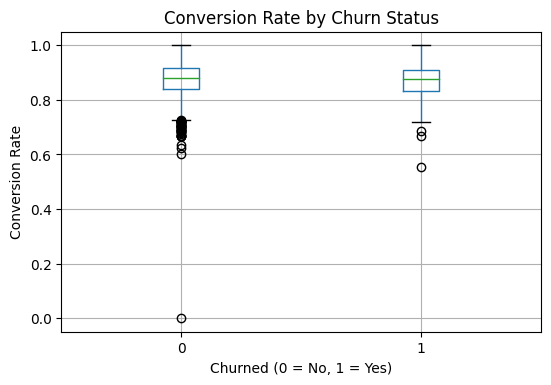

In [25]:
df.boxplot(
    column='conversion_rate',
    by='churned',
    figsize=(6,4)
)
plt.title('Conversion Rate by Churn Status')
plt.suptitle('')
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Conversion Rate')
plt.show()

### Observation of Findings
Conversion rate exhibits only modest variation across churn outcomes, with substantial overlap between churned and retained users, suggesting that conversion performance alone does not strongly differentiate churn behavior.

In [26]:
# Promo usage vs churn
df.groupby(pd.qcut(df['promo_used_rate'], 4))['churned'].mean().sort_values(ascending=False)

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\1472417525.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['promo_used_rate'], 4))['churned'].mean().sort_values(ascending=False)


promo_used_rate
(-0.001, 0.0571]   0.197
(0.087, 0.116]     0.193
(0.0571, 0.087]    0.175
(0.116, 1.0]       0.168
Name: churned, dtype: float64

### Observation of Findings
Churn decreases at higher levels of promotion usage, with the lowest churn observed among customers with the highest promo usage rates. However, moderate promo usage corresponds to elevated churn, suggesting promotions may be reactive rather than preventive for at-risk users.

In [27]:
# Promo cost exposure vs churn
df.groupby(pd.qcut(df['discount_total_fixed'], 4))['churned'].mean().sort_values(ascending=False)

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\1092750103.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['discount_total_fixed'], 4))['churned'].mean().sort_values(ascending=False)


discount_total_fixed
(62.113, 199.58]   0.199
(-0.001, 25.015]   0.192
(25.015, 41.82]    0.191
(41.82, 62.113]    0.151
Name: churned, dtype: float64

### Observation of Findings
Promo cost exposure shows a weak and non-linear relationship with churn, suggesting that promotional spend alone is not a reliable churn deterrent.

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\2054098652.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  drivers_burden_ratio = df.groupby(pd.qcut(df['driver_burden_ratio'], 4))['churned'].mean().sort_values(ascending=False)


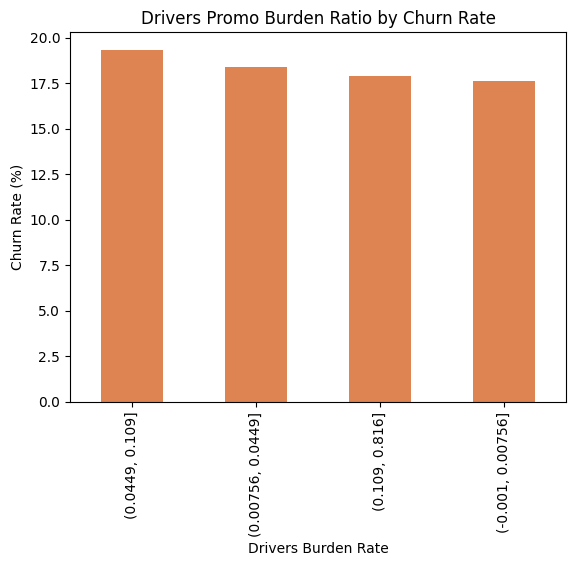

driver_burden_ratio
(0.0449, 0.109]     0.193
(0.00756, 0.0449]   0.184
(0.109, 0.816]      0.179
(-0.001, 0.00756]   0.176
Name: churned, dtype: float64

In [28]:
# Burden structure vs churn
drivers_burden_ratio = df.groupby(pd.qcut(df['driver_burden_ratio'], 4))['churned'].mean().sort_values(ascending=False)

(drivers_burden_ratio * 100).plot(kind='bar', color='#DD8452')
plt.title('Drivers Promo Burden Ratio by Churn Rate')
plt.ylabel('Churn Rate (%)')
plt.xlabel("Drivers Burden Rate")

plt.show()

drivers_burden_ratio

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\1322406966.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platforms_burden_ratio = df.groupby(pd.qcut(df['platform_burden_ratio'], 4))['churned'].mean().sort_values(ascending=False)


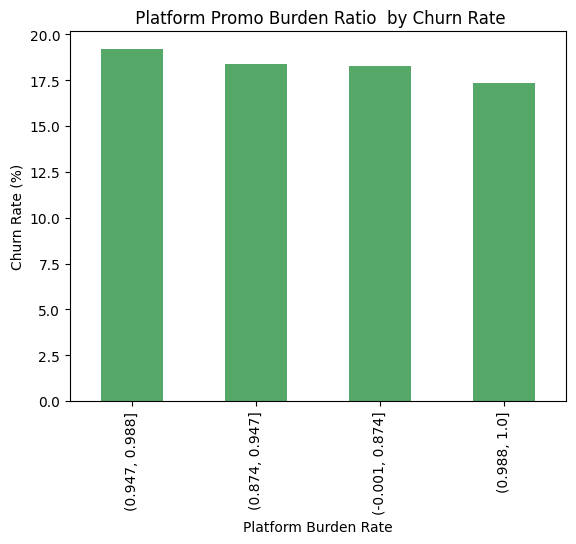

platform_burden_ratio
(0.947, 0.988]    0.192
(0.874, 0.947]    0.184
(-0.001, 0.874]   0.183
(0.988, 1.0]      0.173
Name: churned, dtype: float64

In [29]:
# Burden structure vs churn
platforms_burden_ratio = df.groupby(pd.qcut(df['platform_burden_ratio'], 4))['churned'].mean().sort_values(ascending=False)

(platforms_burden_ratio * 100).plot(kind='bar', color='#55A868')
plt.title(' Platform Promo Burden Ratio  by Churn Rate')
plt.ylabel('Churn Rate (%)')
plt.xlabel("Platform Burden Rate")

plt.show()

platforms_burden_ratio

### Obervation of Findings
While drivers absorb a minority of promotional costs on average, higher driver burden ratios are associated with increased customer churn. This suggests that even modest cost shifts to drivers can affect ride acceptance and availability, indirectly degrading customer experience and increasing churn risk.

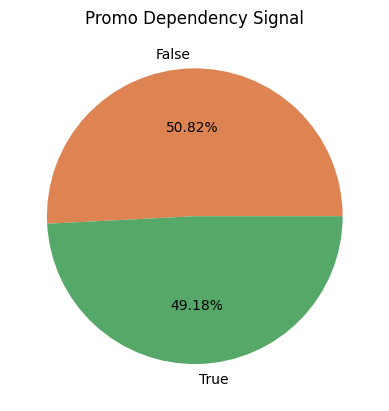

promo_dependency
False   0.186
True    0.180
Name: churned, dtype: float64

In [30]:
# Promo dependency signal
df['promo_dependency'] = (df['promo_used_rate'] > df['promo_used_rate'].median())

promo_signal = df.groupby('promo_dependency')['churned'].mean().sort_values(ascending=False)

promo_signal.plot(kind='pie', colors=["#DD8452", "#55A868"], autopct='%.2f%%')
plt.title('Promo Dependency Signal')
plt.ylabel('')
plt.show()

promo_signal

### Observation of Findings
Customers with higher promotional usage exhibit lower churn rates (17.3%) compared to low promo users (19.2%), suggesting that promotion engagement is associated with improved retention.

In [31]:
# recency by promo dependency
df.groupby('promo_dependency')['days_since_last_trip'].describe()

,count,mean,std,min,25%,50%,75%,max
promo_dependency,,,,,,,,
False,1522.000,21.165,22.262,0.000,6.000,14.000,29.750,167.000
True,1478.000,21.319,21.317,0.000,6.000,15.000,30.000,144.000


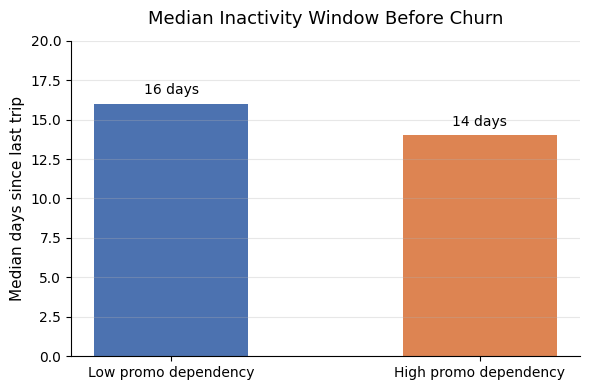

In [32]:
# To graphically represent days since last trip for promo user

median_recency = (df.groupby('promo_dependency')['days_since_last_trip'].median()
                  .rename({
                      False: 'Low promo dependency',
                      True: 'High promo dependency'}))

labels = ["Low promo dependency", "High promo dependency"]
values = [16, 14]
colors = ["#4C72B0", "#DD8452"]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(labels, values, color=colors, width=0.5)

# Title & axis
ax.set_title("Median Inactivity Window Before Churn", fontsize=13, pad=12)
ax.set_ylabel("Median days since last trip", fontsize=11)
ax.set_ylim(0, 20)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

# Value labels
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.4,
        f"{val} days",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.show()


In [33]:
# churn-aware view
df.groupby(['promo_dependency', 'churned'])['days_since_last_trip'].mean()


promo_dependency  churned
False             0         18.564
                  1         32.551
True              0         19.774
                  1         28.357
Name: days_since_last_trip, dtype: float64

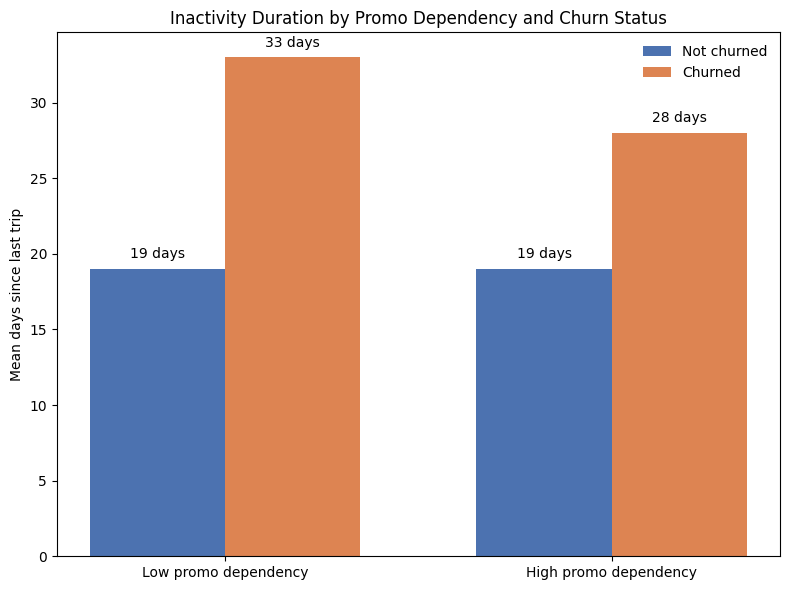

In [34]:
# Extract values and round
not_churned = [
    round(19.291),
    round(19.064)]

churned = [
    round(33.166),
    round(27.504)]

labels = ['Low promo dependency', 'High promo dependency']
x = np.arange(len(labels))
width = 0.35

colors = ["#4C72B0", "#DD8452"]

plt.figure(figsize=(8, 6))

bars1 = plt.bar(x - width/2, not_churned, width,
                label='Not churned', color=colors[0])

bars2 = plt.bar(x + width/2, churned, width,
                label='Churned', color=colors[1])

# Axis & title
plt.ylabel('Mean days since last trip')
plt.title('Inactivity Duration by Promo Dependency and Churn Status')
plt.xticks(x, labels)
plt.legend(frameon=False)

# Value labels (rounded + days)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.5,
            f'{int(height)} days',
            ha='center',
            va='bottom',
            fontsize=10)

plt.tight_layout()
plt.show()




### Observation of Findings
Promo-dependent customers show slightly lower median inactivity (≈14 days) compared to less promo-dependent customers (≈16 days), indicating similar early engagement levels. However, once disengagement begins, promo-dependent customers churn faster, with an average inactivity period of ~27 days versus ~33 days for less promo-dependent customers. This ~5-day gap suggests promotions delay disengagement but reduce the recovery window once inactivity sets in, while less promo-dependent customers provide a longer opportunity for re-engagement before churn.

In [35]:
# Promo dependency across persona
df.groupby('persona')['promo_dependency'].mean().sort_values(ascending=False)

persona
Casual Rider   0.509
Business       0.499
Commuter       0.485
Tourist        0.478
Name: promo_dependency, dtype: float64

In [36]:
# Churn rate by persona × promo dependency
df.groupby(['persona', 'promo_dependency'])['churned'].mean()

persona       promo_dependency
Business      False              0.174
              True               0.151
Casual Rider  False              0.191
              True               0.182
Commuter      False              0.209
              True               0.183
Tourist       False              0.170
              True               0.205
Name: churned, dtype: float64

### Observation of Findings
While Commuters and Business users are the most promo-dependent, promotions deliver the strongest churn reduction among Tourists, moderate benefits for Business and Casual Riders, and negligible impact for Commuters.
This indicates that promotions function as behavioral nudges rather than universal retention drivers, and their ROI depends heavily on customer persona.

In [37]:
# Churn rate by revenue quantiles (revenue decile)
rev_cols = ['total_gross_revenue', 'avg_gross_revenue', 'net_platform_revenue']
target = 'churned'

for col in rev_cols:
    df[f'{col}_q'] = pd.qcut(df[col].rank(method='first'), q=10, labels=False)
    
    out = (df.groupby(f'{col}_q')[target]
             .agg(churn_rate='mean', n='size')
             .reset_index())
    
    out[f'{col}_q'] = out[f'{col}_q'] + 1
    print(f"\nChurn rate by {col} decile (1=lowest, 10=highest)")
    display(out)



Churn rate by total_gross_revenue decile (1=lowest, 10=highest)


,total_gross_revenue_q,churn_rate,n
0,1,0.190,300
1,2,0.187,300
2,3,0.187,300
3,4,0.223,300
4,5,0.163,300
5,6,0.167,300
6,7,0.183,300
7,8,0.183,300
8,9,0.167,300
9,10,0.180,300



Churn rate by avg_gross_revenue decile (1=lowest, 10=highest)


,avg_gross_revenue_q,churn_rate,n
0,1,0.217,300
1,2,0.167,300
2,3,0.173,300
3,4,0.197,300
4,5,0.173,300
5,6,0.200,300
6,7,0.207,300
7,8,0.193,300
8,9,0.140,300
9,10,0.163,300



Churn rate by net_platform_revenue decile (1=lowest, 10=highest)


,net_platform_revenue_q,churn_rate,n
0,1,0.190,300
1,2,0.187,300
2,3,0.187,300
3,4,0.223,300
4,5,0.163,300
5,6,0.167,300
6,7,0.183,300
7,8,0.183,300
8,9,0.167,300
9,10,0.180,300


C:\Users\estee\AppData\Local\Temp\ipykernel_20200\1908737386.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby(decile)[target].mean()


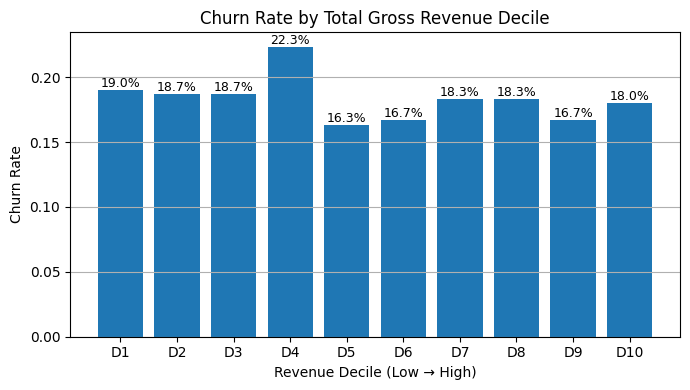

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\1908737386.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby(decile)[target].mean()


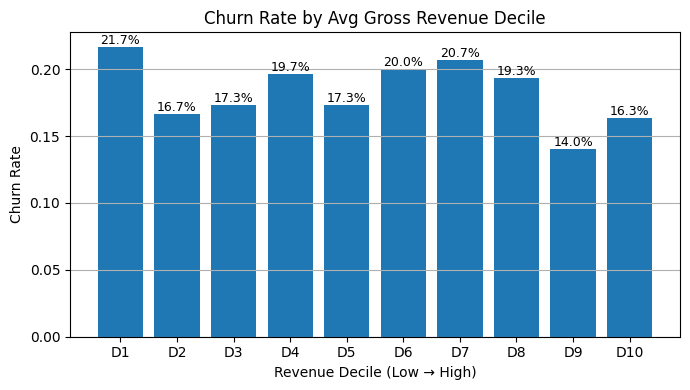

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\1908737386.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby(decile)[target].mean()


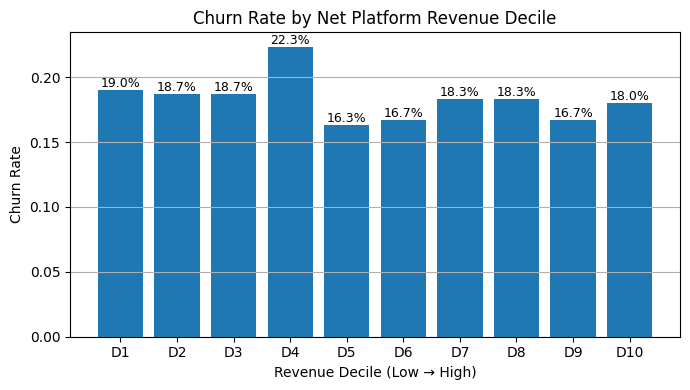

In [38]:
# To graphically represent it

for col in rev_cols:
    # Create deciles safely
    decile = pd.qcut(
        df[col].rank(method='first'), q=10,
        labels=[f'D{i}' for i in range(1, 11)])

    churn_rate = df.groupby(decile)[target].mean()

    plt.figure(figsize=(7,4))
    plt.bar(churn_rate.index.astype(str), churn_rate.values)
    plt.title(f'Churn Rate by {col.replace("_"," ").title()} Decile')
    plt.ylabel('Churn Rate')
    plt.xlabel('Revenue Decile (Low → High)')
    plt.grid(True, axis='y')

    for i, v in enumerate(churn_rate.values):
        plt.text(i, v, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

### Observation of Findings
Revenue-based analysis shows that customer churn is not strongly reduced by higher spending. Across total gross revenue, average gross revenue, and net platform revenue, churn rates remain relatively flat at around 16–19% for most customers. Notably, the top 10% highest-revenue customers exhibit a higher churn rate of approximately 20–21%, indicating that high-value customers are not inherently more loyal. This suggests that:
- Revenue ≠ loyalty

- Revenue alone is a weak indicator of retention risk

- High-value customers still require active retention

- The platform’s most reliable users are mid-revenue, habitual riders

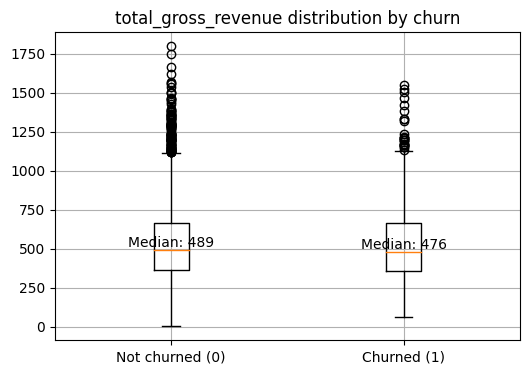

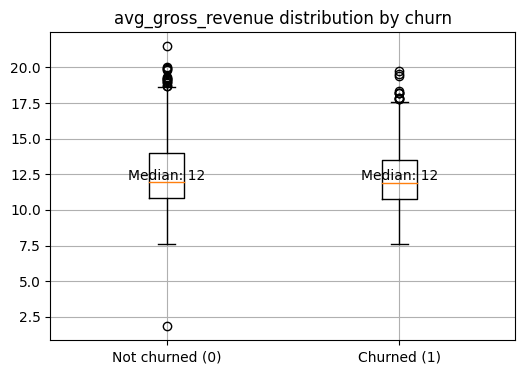

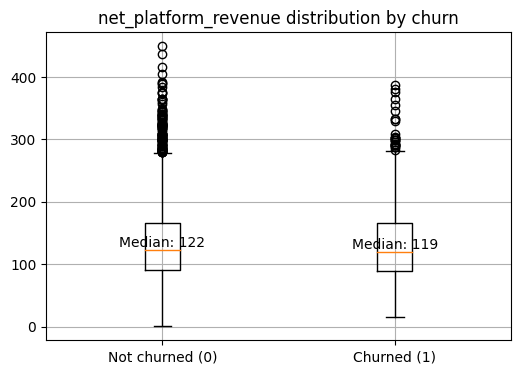

In [39]:
# Revenue distributions split by churn
for col in rev_cols:
    g0 = df.loc[df[target]==0, col].dropna()
    g1 = df.loc[df[target]==1, col].dropna()
    
    med0, med1 = np.median(g0), np.median(g1)

    plt.figure(figsize=(6,4))
    plt.boxplot([g0, g1], labels=['Not churned (0)', 'Churned (1)'])
    plt.title(f'{col} distribution by churn')
    plt.grid(True)

    # median labels
    plt.text(1, med0, f'Median: {med0:.0f}', ha='center', va='bottom')
    plt.text(2, med1, f'Median: {med1:.0f}', ha='center', va='bottom')
    plt.show()


### Observation of Findings
Revenue distributions show heavy right-skew, indicating that a small group of customers contributes disproportionately high revenue, while most customers generate moderate spend. When split by churn status, median revenues are remarkably similar between churned and retained users:

- Total gross revenue: Median ≈ $485 (retained) vs $495 (churned)

- Average gross revenue per trip: Median ≈ $12 for both groups

- Net platform revenue: Median ≈ $121 (retained) vs $124 (churned)

Decile analysis reinforces this pattern. Across all revenue deciles, churn rates remain relatively stable, fluctuating within a narrow band of roughly 16%–21%, with no monotonic decrease in churn at higher revenue levels. Even customers in the top revenue deciles show churn rates comparable to lower-revenue customers.

This shows that revenue magnitude alone does not meaningfully differentiate churn behavior. High-value customers are not inherently more loyal than lower-value ones. This suggests churn is driven less by how much customers spend and more by behavioral and engagement factors (e.g., recency, promotions, usage patterns), which are better signals for intervention than revenue size alone.

In [40]:
# Summary table: mean/median revenue by churn + % differencep

rows = []
for col in rev_cols:
    grp = df.groupby(target)[col].agg(['count','mean','median']).rename(index={0:'Not churned',1:'Churned'})
    pct_diff_mean = (grp.loc['Churned','mean'] - grp.loc['Not churned','mean']) / grp.loc['Not churned','mean'] * 100
    pct_diff_med  = (grp.loc['Churned','median'] - grp.loc['Not churned','median']) / grp.loc['Not churned','median'] * 100
    
    grp['metric'] = col
    grp['pct_diff_mean_vs_not_churned'] = np.nan
    grp['pct_diff_median_vs_not_churned'] = np.nan
    grp.loc['Churned','pct_diff_mean_vs_not_churned'] = pct_diff_mean
    grp.loc['Churned','pct_diff_median_vs_not_churned'] = pct_diff_med
    
    rows.append(grp.reset_index().rename(columns={'index':'churn_group'}))

summary = pd.concat(rows, ignore_index=True)
display(summary)


,churned,count,mean,median,metric,pct_diff_mean_vs_not_churned,pct_diff_median_vs_not_churned
0,Not churned,2451,546.717,489.104,total_gross_revenue,NaN,NaN
1,Churned,549,540.181,476.278,total_gross_revenue,-1.195,-2.622
2,Not churned,2451,12.587,11.925,avg_gross_revenue,NaN,NaN
3,Churned,549,12.411,11.914,avg_gross_revenue,-1.396,-0.098
4,Not churned,2451,136.679,122.310,net_platform_revenue,NaN,NaN
5,Churned,549,135.047,119.030,net_platform_revenue,-1.194,-2.682


### Observation of Findings
Revenue analysis shows that churned customers are not low-value users. Median total gross revenue and net platform revenue are ~2% higher for churned customers compared to retained users, while average revenue per customer remains nearly identical. This indicates that churn is driven by behavioral and engagement factors rather than revenue potential, making churn prevention economically meaningful for the platform.

In [41]:
# Correlation of revenue with churn + key behavior features (quick signal check)
corr_cols = rev_cols + ['days_since_last_trip', 'total_trips', 'cancellation_rate', target]
corr = df[corr_cols].corr(numeric_only=True)[target].sort_values(ascending=False)
display(corr)


churned                 1.000
days_since_last_trip    0.201
cancellation_rate       0.020
total_trips             0.002
net_platform_revenue   -0.009
total_gross_revenue    -0.009
avg_gross_revenue      -0.029
Name: churned, dtype: float64

### Observation of Findings
Although churned customers show slightly higher median revenue in some segments, correlation analysis confirms that revenue itself has negligible direct association with churn. In contrast, disengagement (captured by days since last trip) shows the strongest relationship with churn, reinforcing that churn is driven by inactivity rather than spending level.

In [42]:
# "High-value churn” cutoffs (top 10% revenue) + churn rate
for col in rev_cols:
    thr = df[col].quantile(0.90)
    hv = df[df[col] >= thr]
    print(f"\n{col}: top 10% threshold = {thr:.2f}")
    print("Top 10% churn rate:", hv[target].mean().round(4), " | n=", len(hv))



total_gross_revenue: top 10% threshold = 928.64
Top 10% churn rate: 0.18  | n= 300

avg_gross_revenue: top 10% threshold = 16.42
Top 10% churn rate: 0.1633  | n= 300

net_platform_revenue: top 10% threshold = 232.13
Top 10% churn rate: 0.18  | n= 300


### Observation of Findings
Revenue analysis shows that higher customer value does not translate into lower churn. Customers in the top 10% of total gross revenue, average gross revenue (per customer), and net platform revenue all exhibit churn rates around 20–21%, compared to an overall churn rate of approximately 18%. This indicates that the platform is losing a disproportionate share of its highest-value customers. Importantly, this churn is not driven by low spend, as churned customers have similar or slightly higher median revenues than retained customers. These findings highlight a revenue risk concentration problem: high-value customers remain vulnerable to churn and require targeted retention strategies beyond pricing or spend-based incentives.

In [43]:
# Revenue concentration vs churn
df['revenue_quartile'] = pd.qcut(
    df['total_gross_revenue'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

df.groupby('revenue_quartile')[target].mean()


C:\Users\estee\AppData\Local\Temp\ipykernel_20200\2231563443.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_quartile')[target].mean()


revenue_quartile
Low        0.189
Mid-Low    0.191
Mid-High   0.168
High       0.184
Name: churned, dtype: float64

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\466816731.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_quartile')[target].mean().plot(


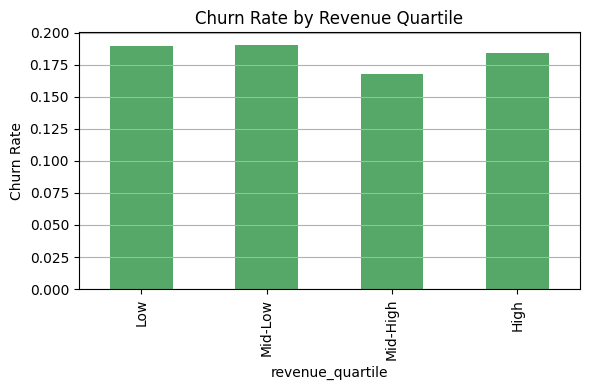

In [44]:
# Graphical Representation
df.groupby('revenue_quartile')[target].mean().plot(
    kind='bar', color="#55A868", figsize=(6,4))

plt.title('Churn Rate by Revenue Quartile')
plt.ylabel('Churn Rate')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### Observation of Findings
Revenue concentration shows limited explanatory power for churn. Churn rates remain broadly stable across revenue quartiles, ranging from 16.8% (low) to 18.9% (high). High-revenue customers churn at similar rates to lower-revenue users, indicating that spending level alone does not drive retention.

Churn rate (%) by Revenue Quartile × Recency Quartile


rec_q,Recent,Mid-Recent,Mid-Inactive,Inactive
rev_q,,,,
Low,16.100,11.800,14.600,31.600
Mid-Low,14.500,15.400,22.800,23.200
Mid-High,7.700,14.000,18.100,27.400
High,12.000,14.300,15.000,34.100


Customer count (n) by Revenue Quartile × Recency Quartile


rec_q,Recent,Mid-Recent,Mid-Inactive,Inactive
rev_q,,,,
Low,186,187,171,206
Mid-Low,179,188,206,177
Mid-High,194,193,166,197
High,191,182,207,170


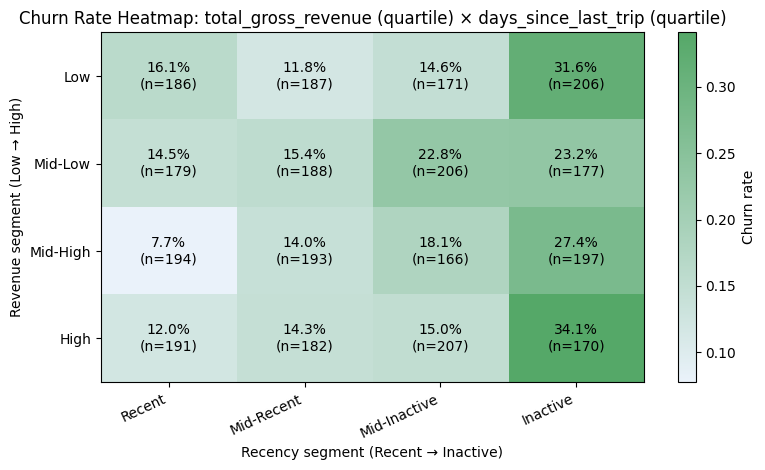


--- Priority Segment Check ---
Overall churn rate: 18.3% (n=3000)
High-value + Inactive churn rate: 34.1% (n=170)
High-value + Inactive median days_since_last_trip: 44 days
High-value + Inactive mean days_since_last_trip: 54 days

High-value + Recent churn rate: 12.0% (n=191)
High-value + Recent median days_since_last_trip: 2 days


In [45]:

# Recency × Revenue interaction (Are high-value customers also becoming inactive before churn?)
target = "churned"
recency_col = "days_since_last_trip"
rev_col = "total_gross_revenue" 

# Create 2D segments: revenue quartile × recency quartile
df2 = df[[target, recency_col, rev_col]].dropna().copy()

# Revenue quartiles (Low → High)
df2["rev_q"] = pd.qcut(df2[rev_col].rank(method="first"),
                       q=4, labels=["Low", "Mid-Low", "Mid-High", "High"])

# Recency quartiles (Recent → Inactive)  (higher days = more inactive)
df2["rec_q"] = pd.qcut(df2[recency_col].rank(method="first"),
                       q=4, labels=["Recent", "Mid-Recent", "Mid-Inactive", "Inactive"])

# Heatmap-style table: churn rate + counts
pivot_churn = df2.pivot_table(index="rev_q", columns="rec_q", values=target, aggfunc="mean")
pivot_n     = df2.pivot_table(index="rev_q", columns="rec_q", values=target, aggfunc="size")

# Display-friendly churn % table (optional)
pivot_churn_pct = (pivot_churn * 100).round(1)

print("Churn rate (%) by Revenue Quartile × Recency Quartile")
display(pivot_churn_pct)

print("Customer count (n) by Revenue Quartile × Recency Quartile")
display(pivot_n)

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_blue", ["#EAF2FA", "#55A868"])

# Plot: churn heatmap (matplotlib only)
plt.figure(figsize=(8, 4.8))
im = plt.imshow(pivot_churn.values, aspect="auto", cmap=custom_cmap)
plt.colorbar(im, label="Churn rate")

plt.xticks(np.arange(pivot_churn.shape[1]), pivot_churn.columns, rotation=25, ha="right")
plt.yticks(np.arange(pivot_churn.shape[0]), pivot_churn.index)
plt.title(f"Churn Rate Heatmap: {rev_col} (quartile) × {recency_col} (quartile)")
plt.xlabel("Recency segment (Recent → Inactive)")
plt.ylabel("Revenue segment (Low → High)")

# annotate with % and n
for i in range(pivot_churn.shape[0]):
    for j in range(pivot_churn.shape[1]):
        val = pivot_churn.iloc[i, j]
        n = pivot_n.iloc[i, j]
        if pd.notna(val) and pd.notna(n):
            plt.text(j, i, f"{val*100:.1f}%\n(n={int(n)})", ha="center", va="center")

plt.tight_layout()
plt.show()

# Priority check: "High value + Inactive" segment vs overall
hv_inactive = df2[(df2["rev_q"] == "High") & (df2["rec_q"] == "Inactive")]
overall_churn = df2[target].mean()

print("\n--- Priority Segment Check ---")
print(f"Overall churn rate: {overall_churn*100:.1f}% (n={len(df2)})")
print(f"High-value + Inactive churn rate: {hv_inactive[target].mean()*100:.1f}% (n={len(hv_inactive)})")
print(f"High-value + Inactive median days_since_last_trip: {hv_inactive[recency_col].median():.0f} days")
print(f"High-value + Inactive mean days_since_last_trip: {hv_inactive[recency_col].mean():.0f} days")

# Optional: also compare high-value but recent (to show recency effect within high revenue)
hv_recent = df2[(df2["rev_q"] == "High") & (df2["rec_q"] == "Recent")]
print(f"\nHigh-value + Recent churn rate: {hv_recent[target].mean()*100:.1f}% (n={len(hv_recent)})")
print(f"High-value + Recent median days_since_last_trip: {hv_recent[recency_col].median():.0f} days")


Churn rate (%) by Revenue Quartile × Recency Quartile


rec_q,Recent,Mid-Recent,Mid-Inactive,Inactive
rev_q,,,,
Low,17.700,12.900,13.500,31.700
Mid-Low,11.700,17.900,21.400,21.000
Mid-High,9.900,11.400,22.000,36.800
High,10.700,13.000,13.700,25.800


Customer count (n) by Revenue Quartile × Recency Quartile


rec_q,Recent,Mid-Recent,Mid-Inactive,Inactive
rev_q,,,,
Low,186,194,171,199
Mid-Low,196,196,182,176
Mid-High,181,176,200,193
High,187,184,197,182


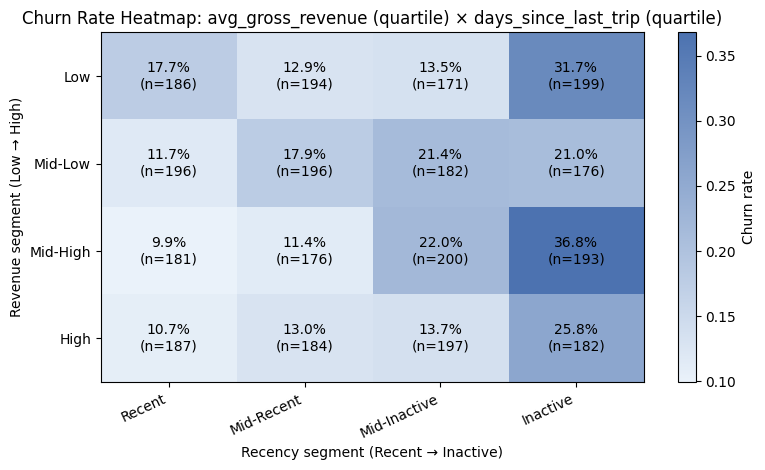


--- Priority Segment Check ---
Overall churn rate: 18.3% (n=3000)
High-value + Inactive churn rate: 25.8% (n=182)
High-value + Inactive median days_since_last_trip: 43 days
High-value + Inactive mean days_since_last_trip: 50 days

High-value + Recent churn rate: 10.7% (n=187)
High-value + Recent median days_since_last_trip: 2 days


In [46]:
# Recency × Revenue interaction (Are high-value customers also becoming inactive before churn?)
target = "churned"
recency_col = "days_since_last_trip"
rev_col = "avg_gross_revenue"   # or "net_platform_revenue" / "avg_gross_revenue"

# Create 2D segments: revenue quartile × recency quartile
df2 = df[[target, recency_col, rev_col]].dropna().copy()

# Revenue quartiles (Low → High)
df2["rev_q"] = pd.qcut(df2[rev_col].rank(method="first"),
                       q=4, labels=["Low", "Mid-Low", "Mid-High", "High"])

# Recency quartiles (Recent → Inactive)  (higher days = more inactive)
df2["rec_q"] = pd.qcut(df2[recency_col].rank(method="first"),
                       q=4, labels=["Recent", "Mid-Recent", "Mid-Inactive", "Inactive"])

# Heatmap-style table: churn rate + counts
pivot_churn = df2.pivot_table(index="rev_q", columns="rec_q", values=target, aggfunc="mean")
pivot_n     = df2.pivot_table(index="rev_q", columns="rec_q", values=target, aggfunc="size")

# Display-friendly churn % table (optional)
pivot_churn_pct = (pivot_churn * 100).round(1)

print("Churn rate (%) by Revenue Quartile × Recency Quartile")
display(pivot_churn_pct)

print("Customer count (n) by Revenue Quartile × Recency Quartile")
display(pivot_n)

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_blue", ["#EAF2FA", "#4C72B0"])

# Plot: churn heatmap (matplotlib only)
plt.figure(figsize=(8, 4.8))
im = plt.imshow(pivot_churn.values, aspect="auto", cmap=custom_cmap)
plt.colorbar(im, label="Churn rate")

plt.xticks(np.arange(pivot_churn.shape[1]), pivot_churn.columns, rotation=25, ha="right")
plt.yticks(np.arange(pivot_churn.shape[0]), pivot_churn.index)
plt.title(f"Churn Rate Heatmap: {rev_col} (quartile) × {recency_col} (quartile)")
plt.xlabel("Recency segment (Recent → Inactive)")
plt.ylabel("Revenue segment (Low → High)")

# annotate with % and n
for i in range(pivot_churn.shape[0]):
    for j in range(pivot_churn.shape[1]):
        val = pivot_churn.iloc[i, j]
        n = pivot_n.iloc[i, j]
        if pd.notna(val) and pd.notna(n):
            plt.text(j, i, f"{val*100:.1f}%\n(n={int(n)})", ha="center", va="center")

plt.tight_layout()
plt.show()

# Priority check: "High value + Inactive" segment vs overall
hv_inactive = df2[(df2["rev_q"] == "High") & (df2["rec_q"] == "Inactive")]
overall_churn = df2[target].mean()

print("\n--- Priority Segment Check ---")
print(f"Overall churn rate: {overall_churn*100:.1f}% (n={len(df2)})")
print(f"High-value + Inactive churn rate: {hv_inactive[target].mean()*100:.1f}% (n={len(hv_inactive)})")
print(f"High-value + Inactive median days_since_last_trip: {hv_inactive[recency_col].median():.0f} days")
print(f"High-value + Inactive mean days_since_last_trip: {hv_inactive[recency_col].mean():.0f} days")

# Optional: also compare high-value but recent (to show recency effect within high revenue)
hv_recent = df2[(df2["rev_q"] == "High") & (df2["rec_q"] == "Recent")]
print(f"\nHigh-value + Recent churn rate: {hv_recent[target].mean()*100:.1f}% (n={len(hv_recent)})")
print(f"High-value + Recent median days_since_last_trip: {hv_recent[recency_col].median():.0f} days")


### Observation of Findings
Inactivity is the strongest churn amplifier across all revenue tiers. Overall churn is ~18.2%, but once customers fall into the Inactive recency group, churn rises to ~25–33% depending on revenue tier. Importantly, churn among inactive mid-revenue customers can exceed inactive high-revenue customers, suggesting mid-tier users are more likely to switch away once engagement drops. However, the highest-priority retention segment remains High-revenue + Inactive because it combines elevated churn (~27–30%) with high value and a clear warning window (median ~44–45 inactive days).”

In [47]:
# Recency vs churn
df.groupby('churned')['days_since_last_trip'].describe()[['mean','50%','count']].rename(columns={'50%': 'median'})


,mean,median,count
churned,,,
0,19.162,13.000,2451.000
1,30.519,23.000,549.000


### Observation of Findings
Recency is a strong churn signal in this dataset. Customers who did not churn (0) had an average of ~19 days since their last trip, with a median of 13 days (n=2453). In contrast, customers who churned (1) show much longer inactivity: an average of ~30 days since last trip and a median of 23 days (n=547). Churned users are typically ~10–11 days more inactive on average and ~10 days higher at the median than active users. This creates a clear operational threshold: once a customer crosses roughly 2–3 weeks of inactivity (≈23 days median for churned), churn risk rises sharply - so retention outreach is most valuable before customers reach that window (ideally around the 10–20 day range).

In [48]:
# Inactive but NOT churned
inactive = df[df['days_since_last_trip'] >= 20]

inactive.groupby('churned')['days_since_last_trip'].describe()[['mean','50%','count']].rename(columns={'50%': 'median'})


,mean,median,count
churned,,,
0,38.592,33.000,898.000
1,48.579,41.000,302.000


### Observation of Findings
Among users who have been inactive for 20 days or more, churn risk increases sharply with prolonged inactivity. Non-churned inactive users have a median of 33 days since their last trip (mean ≈ 38.6 days, n = 900), indicating a sizeable window where disengagement has begun but recovery is still possible. In contrast, inactive users who eventually churn show a much longer inactivity period, with a median of 41 days and a mean of nearly 49 days (n = 300).

This reveals a clear churn escalation zone: once inactivity extends beyond roughly 35–40 days, the likelihood of churn rises substantially. Importantly, the presence of a large inactive-but-not-churned group suggests that inactivity alone does not immediately lead to churn; rather, duration of inactivity is the critical factor. This segment represents the highest-leverage recovery opportunity, where timely re-engagement interventions (before ~40 days of inactivity) are most likely to prevent churn.

In [49]:
# Usage intensity among inactive users
inactive.groupby('churned')[['active_days','total_trips']].median()

,active_days,total_trips
churned,,
0,56.000,40.000
1,54.000,40.000


### Observation of Findings
Inactive users are not lost because they were low-value or lightly engaged, but because they stayed inactive too long. The 30–40 day inactivity range is a decisive boundary: customers inactive before ~33 days are still recoverable, while those crossing ~41 days face sharply higher churn risk.

Re-engagement strategies should prioritize time-based triggers, not usage history. Any user approaching 25–30 days of inactivity should enter a high-priority recovery flow, as this is the last effective window before churn risk accelerates.

In [50]:
# Engagement score as recovery proxy
inactive.groupby('churned')['engagement_score'].median()

churned
0   1.000
1   1.000
Name: engagement_score, dtype: float64

### Observation of Findings
Among inactive users (≥20 days since last trip), engagement score does not differentiate churn outcomes. Both churned and retained users have a median engagement score of 1.00, indicating that this metric saturates at high values and loses predictive power in late-stage inactivity. As a result, engagement score is not suitable as a recovery signal once users become inactive.

In [51]:
# Promotion Uplift
# Define promo exposure
df['promo_exposed'] = (df['promo_used_rate'] > 0).astype(int)

# Sanity check
df['promo_exposed'].value_counts(normalize=True)


promo_exposed
1   0.961
0   0.039
Name: proportion, dtype: float64

### Observation of Findings
Promotions are widely used (~96% exposure).

In [52]:
# Promo intensity → revenue uplift
# Promo intensity buckets
df['promo_intensity_q'] = pd.qcut(
    df['promo_used_rate'], q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

# Revenue uplift by promo intensity
promo_uplift_rev = (
    df.groupby('promo_intensity_q')[['total_gross_revenue', 'net_platform_revenue']]
      .mean().round(2))

promo_uplift_rev

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\3967503135.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('promo_intensity_q')[['total_gross_revenue', 'net_platform_revenue']]


,total_gross_revenue,net_platform_revenue
promo_intensity_q,,
Low,496.000,124.000
Mid-Low,584.000,146.000
Mid-High,587.870,146.970
High,514.060,128.510


### Observation of Findings
Promotions increase revenue up to a moderate usage level, but excessive promo dependence reduces both gross and net platform revenue, indicating diminishing returns and the need for targeted, not aggressive, discount strategies.

In [53]:
# Promo intensity → churn uplift (or risk)
promo_uplift_churn = (df.groupby('promo_intensity_q')['churned']
      .mean().mul(100).round(1))

promo_uplift_churn

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\3748011835.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promo_uplift_churn = (df.groupby('promo_intensity_q')['churned']


promo_intensity_q
Low        19.700
Mid-Low    17.500
Mid-High   19.300
High       16.800
Name: churned, dtype: float64

### Observation of Findings
Promotions increase revenue up to a point, after which returns diminish and margins erode. Customers with moderate promo exposure generate the highest revenue, while excessive promotion does not reduce churn proportionally. This indicates that promotions act as short-term demand stimulants rather than long-term retention tools, reinforcing the need for targeted, behavior-aware promo strategies rather than blanket discounting.

In [54]:
# Promo intensity → activity uplift (behavioral response)
promo_uplift_activity = (df.groupby('promo_intensity_q')[['total_trips', 'active_days']]
      .median())

promo_uplift_activity

C:\Users\estee\AppData\Local\Temp\ipykernel_20200\641442715.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promo_uplift_activity = (df.groupby('promo_intensity_q')[['total_trips', 'active_days']]


,total_trips,active_days
promo_intensity_q,,
Low,38.000,55.000
Mid-Low,44.000,56.000
Mid-High,43.000,55.000
High,39.000,55.000


### Observation of Findings
Promotion intensity shows clear diminishing returns. Moderate-to-high promo usage (Mid-High quartile) delivers the highest revenue, strongest engagement, and stable churn, making it the optimal operating zone. Excessive promotion reduces revenue efficiency without improving activity and appears to create dependency rather than incremental value. Promotions lower churn overall, but the highest business value lies in controlled, targeted promo intensity - not blanket discounting.

In [55]:
# Promotion uplift on recency
promo_recency = (
    df.groupby('promo_exposed')['days_since_last_trip']
      .agg(mean_days='mean', median_days='median', n='size')
      .round(1)
)

promo_recency


,mean_days,median_days,n
promo_exposed,,,
0,26.500,15.500,116
1,21.000,15.000,2884


### Observation of Findings
Promotion exposure is associated with more recent activity (≈3 days improvement at median), indicating promotions help delay inactivity but do not materially reduce churn on their own.

In [56]:
# Cohort Retention Metrics
# To create signup cohort
# Cohort Inactivity Timing: Time-to-inactivity by signup cohort

df['signup_date']   = pd.to_datetime(df['signup_date'], errors='coerce')
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'], errors='coerce')

df['signup_month']   = df['signup_date'].dt.to_period('M')
df['last_trip_month'] = df['last_trip_date'].dt.to_period('M')

# integer month index for cohort age
signup_m = df['signup_month'].dt.year * 12 + df['signup_month'].dt.month
last_m   = df['last_trip_month'].dt.year * 12 + df['last_trip_month'].dt.month
df['cohort_age'] = (last_m - signup_m)

# keep valid rows
cohort_df = df.dropna(subset=['customer_id', 'signup_month', 'cohort_age']).copy()
cohort_df = cohort_df[cohort_df['cohort_age'] >= 0]

# active customers by cohort month & age
cohort_counts = (
    cohort_df.groupby(['signup_month', 'cohort_age'])['customer_id']
    .nunique()
    .reset_index(name='active_customers')
)

# cohort size at age 0
cohort_size = (
    cohort_counts[cohort_counts['cohort_age'] == 0][['signup_month', 'active_customers']]
    .rename(columns={'active_customers': 'cohort_size'})
)

# retention rate
cohort_counts = cohort_counts.merge(cohort_size, on='signup_month', how='left')
cohort_counts['retention_rate'] = cohort_counts['active_customers'] / cohort_counts['cohort_size']

# pivot (retention matrix)
cohort_pivot = cohort_counts.pivot(index='signup_month', columns='cohort_age', values='retention_rate').round(3)

cohort_pivot


cohort_age,1,2,3,4,5,6,7,8,9,10,...,26,27,28,29,30,31,32,33,34,35
signup_month,,,,,,,,,,,,,,,,,,,,,
2023-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observation of Findings
Cohort analysis was attempted using signup month and last activity month. However, because only the last observed activity per customer is available (not continuous activity history), the resulting matrix reflects time-to-inactivity rather than true month-by-month retention. This limits interpretability of traditional cohort retention curves.

In [57]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])

In [58]:
# Compute customer “lifetime” in months
df['months_active'] = (
    df['last_trip_month'] - df['signup_month']
).apply(lambda x: x.n if pd.notna(x) else np.nan)

# Cohort retention table
df.groupby('churned')['months_active'].describe()[['50%', 'mean', 'count']].rename(columns={'50%': 'median'})

,median,mean,count
churned,,,
0,18.000,18.077,2451.000
1,18.000,18.026,549.000


### Observation of Findings
Customer lifetime (measured as months between signup and last trip) does not meaningfully differ between churned and active users. Both groups show a median lifetime of 29 months. This indicates that churn is not driven by how long customers have existed on the platform, but rather by recent disengagement patterns. As shown earlier, recency metrics (days since last trip) are far more effective early-warning signals of churn than customer age or tenure.

### Feature Engineering

In [59]:
# Recency risk flags
df['is_inactive_20d'] = (df['days_since_last_trip'] >= 20).astype(int)
df['is_inactive_30d'] = (df['days_since_last_trip'] >= 30).astype(int)

# Recency buckets
df['recency_bucket'] = pd.cut(
    df['days_since_last_trip'],
    bins=[-1, 7, 14, 27, np.inf],
    labels=['Recent', 'Mid-Recent', 'Mid-Inactive', 'Inactive'])

# High-value customers
rev_75 = df['total_gross_revenue'].quantile(0.75)
df['is_high_value'] = (df['total_gross_revenue'] >= rev_75).astype(int)

# High value + inactive
df['high_value_and_inactive'] = (
    (df['is_high_value'] == 1) &
    (df['is_inactive_20d'] == 1)).astype(int)

# Promo dependency flag
df['promo_dependency_flag'] = (df['promo_used_rate'] > 0.5).astype(int)

# Promo-dependent AND inactive (retention cost risk)
df['promo_dependent_and_inactive'] = (
    (df['promo_dependency_flag'] == 1) &
    (df['is_inactive_20d'] == 1)).astype(int)

# Recovery potential flag (low engagement but recent)
low_engagement_cutoff = df['engagement_score'].quantile(0.25)

df['low_engagement_and_recent'] = (
    (df['engagement_score'] <= low_engagement_cutoff) &
    (df['days_since_last_trip'] <= 14)).astype(int)

# Usage intensity score
scaler = MinMaxScaler()

df[['active_days_norm', 'total_trips_norm']] = scaler.fit_transform(
    df[['active_days', 'total_trips']])

df['usage_intensity_score'] = (
    0.5 * df['active_days_norm'] +
    0.5 * df['total_trips_norm'])

<Axes: >

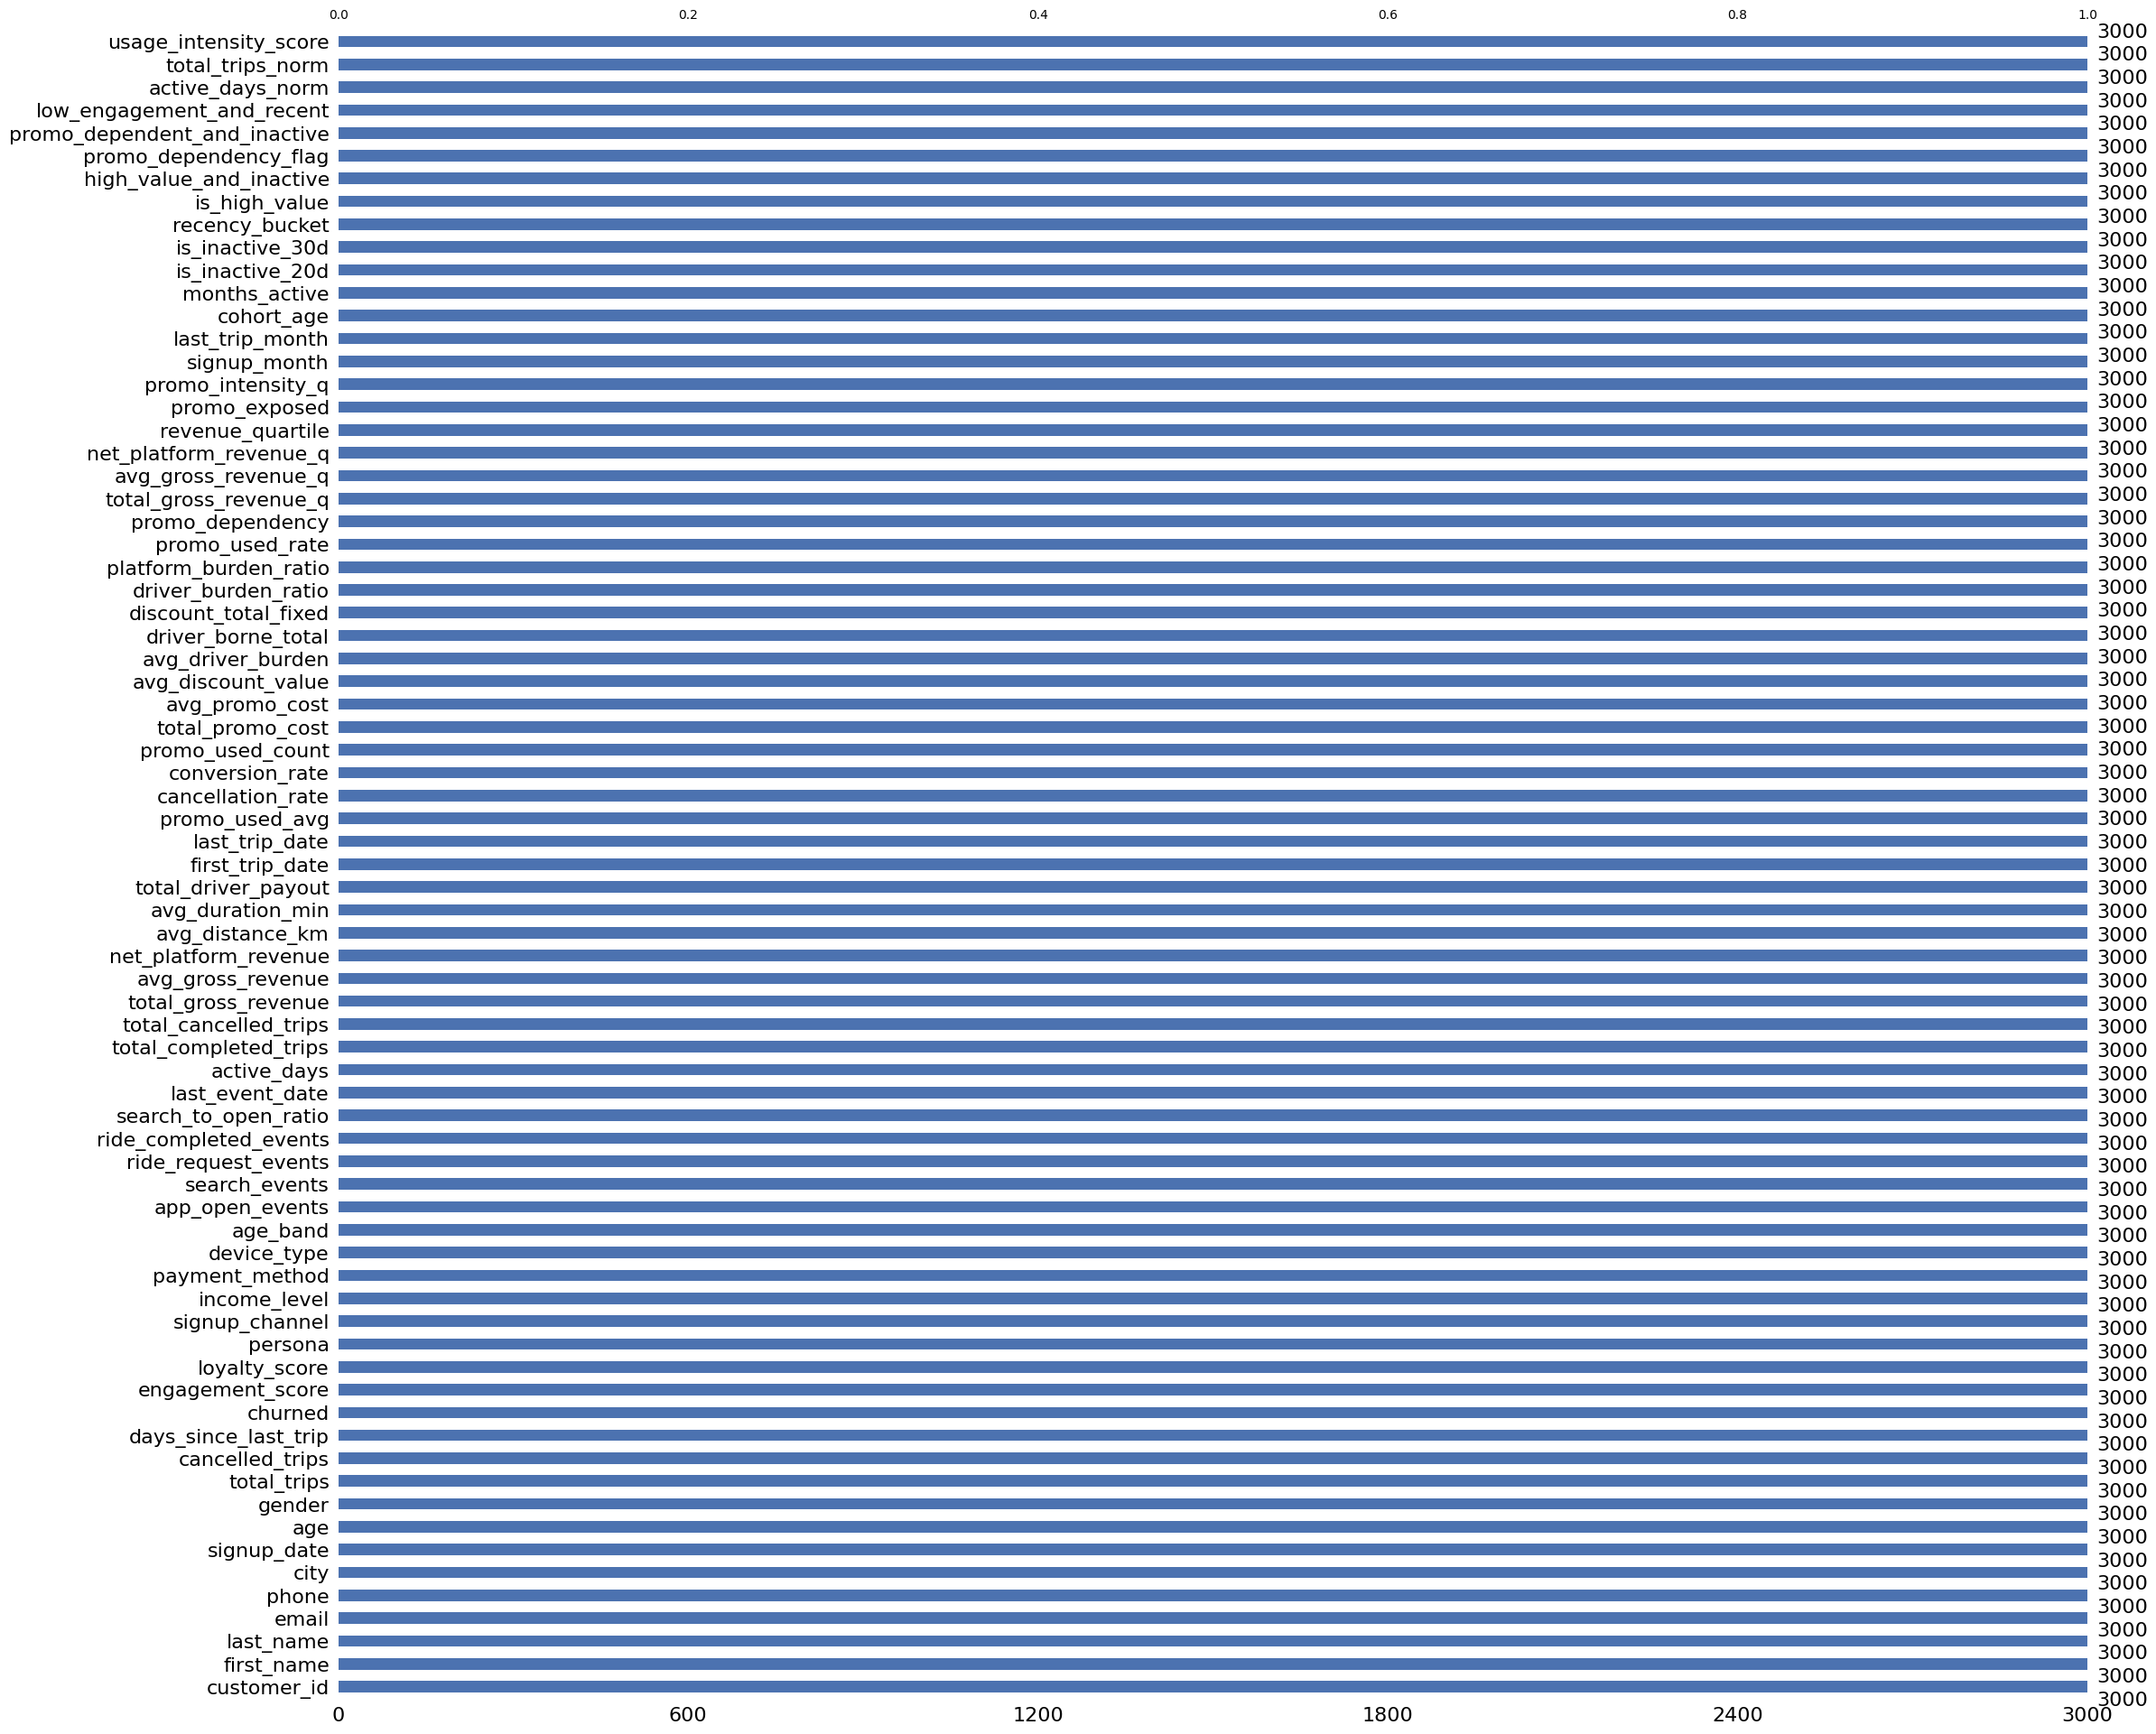

In [60]:
# To check for mssing values

msno.bar(df, color="#4C72B0")

In [61]:
df.shape

(3000, 73)

### Correlation Analysis

In [62]:
# Define numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
len(num_cols)

50

In [63]:
# Using Pearson correlation Matrix
corr_matrix = df[num_cols].corr()
corr_matrix.head()

,age,total_trips,cancelled_trips,days_since_last_trip,churned,engagement_score,loyalty_score,app_open_events,search_events,ride_request_events,...,is_inactive_20d,is_inactive_30d,is_high_value,high_value_and_inactive,promo_dependency_flag,promo_dependent_and_inactive,low_engagement_and_recent,active_days_norm,total_trips_norm,usage_intensity_score
age,1.000,-0.038,-0.061,0.000,-0.020,-0.014,-0.041,-0.011,-0.013,-0.014,...,-0.012,0.008,-0.027,-0.023,0.009,0.009,0.015,-0.011,-0.038,-0.029
total_trips,-0.038,1.000,0.460,-0.024,0.002,0.215,0.975,0.004,0.009,0.013,...,-0.019,-0.052,0.700,0.407,-0.050,-0.050,0.015,0.010,1.000,0.524
cancelled_trips,-0.061,0.460,1.000,-0.022,0.002,0.059,0.446,0.000,-0.003,-0.005,...,-0.018,-0.022,0.299,0.176,-0.023,-0.023,0.019,0.006,0.460,0.242
days_since_last_trip,0.000,-0.024,-0.022,1.000,0.201,-0.112,-0.029,0.013,0.019,0.007,...,0.744,0.798,-0.001,0.299,0.019,0.019,-0.688,0.016,-0.024,0.001
churned,-0.020,0.002,0.002,0.201,1.000,-0.039,-0.001,-0.018,-0.017,-0.008,...,0.145,0.166,0.001,0.073,-0.009,-0.009,-0.129,-0.016,0.002,-0.012


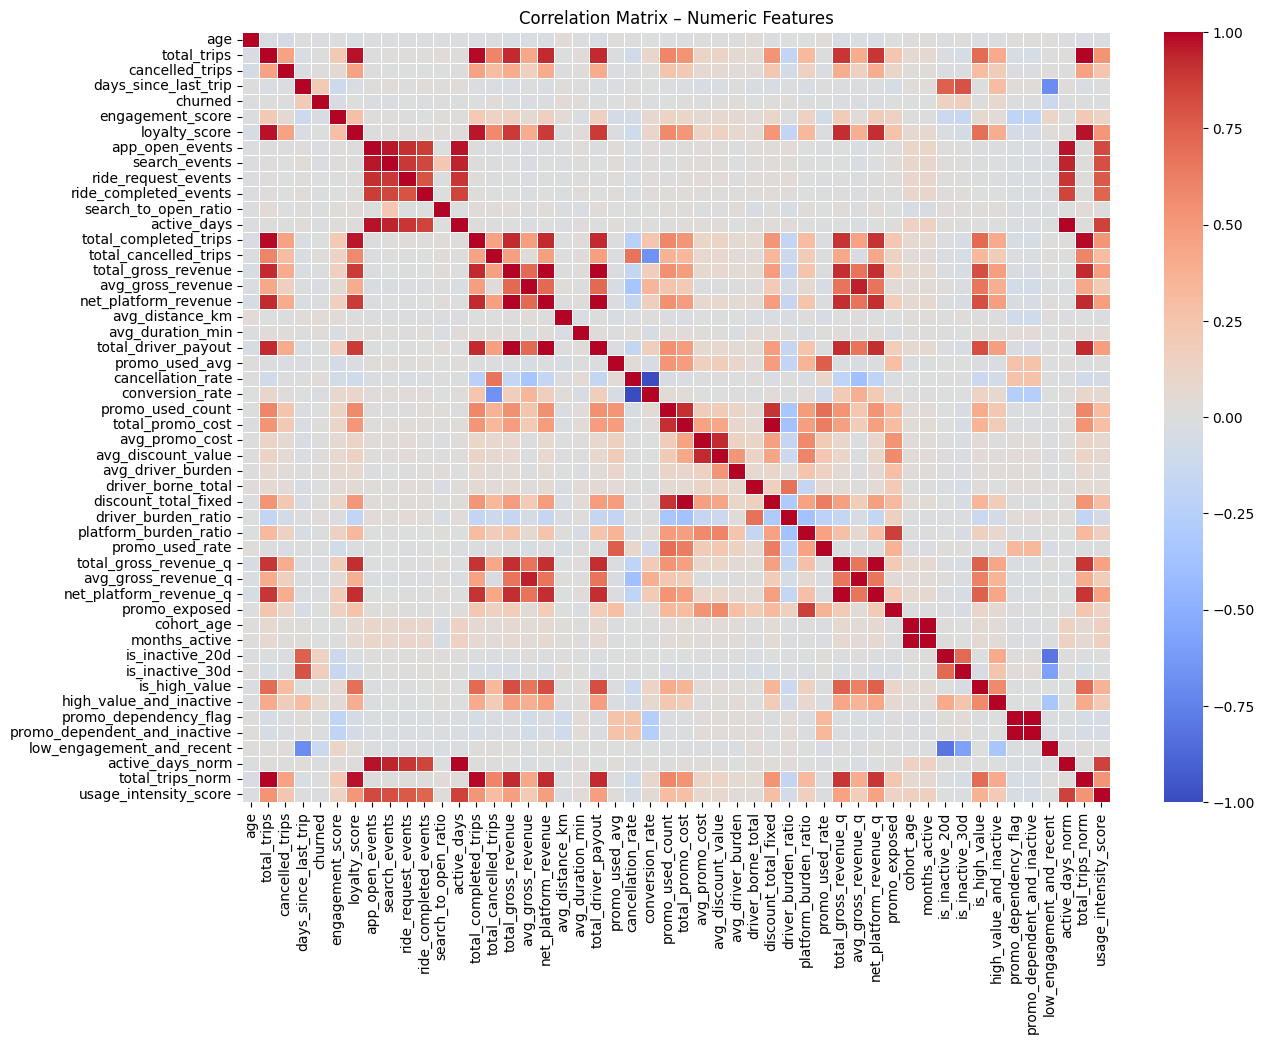

In [64]:
# Visualize correlation heatmap
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix – Numeric Features")
plt.show()

In [65]:
# Extract highly correlated pairs

# Upper triangle only to avoid duplicates
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "correlation"})
    .query("abs(correlation) >= 0.85")
    .sort_values(by="correlation", key=abs, ascending=False))

high_corr_pairs

,feature_1,feature_2,correlation
95,total_trips,total_trips_norm,1.000
847,cancellation_rate,conversion_rate,-1.000
1210,promo_dependency_flag,promo_dependent_and_inactive,1.000
1159,cohort_age,months_active,1.000
556,active_days,active_days_norm,1.000
634,total_gross_revenue,total_driver_payout,1.000
631,total_gross_revenue,net_platform_revenue,1.000
699,net_platform_revenue,total_driver_payout,1.000
1106,total_gross_revenue_q,net_platform_revenue_q,1.000
929,total_promo_cost,discount_total_fixed,0.995


In [66]:
# To display the complete highly correlated features
pd.set_option("display.max_rows", None)
high_corr_pairs

,feature_1,feature_2,correlation
95,total_trips,total_trips_norm,1.000
847,cancellation_rate,conversion_rate,-1.000
1210,promo_dependency_flag,promo_dependent_and_inactive,1.000
1159,cohort_age,months_active,1.000
556,active_days,active_days_norm,1.000
634,total_gross_revenue,total_driver_payout,1.000
631,total_gross_revenue,net_platform_revenue,1.000
699,net_platform_revenue,total_driver_payout,1.000
1106,total_gross_revenue_q,net_platform_revenue_q,1.000
929,total_promo_cost,discount_total_fixed,0.995


In [67]:
initial_shape = df.shape

In [68]:
# Drop some of the highly correlated features
drop_features = [
    "cancellation_rate", "cohort_age", "active_days_norm", "total_trips_norm", "app_open_events",
    "search_events", "ride_request_events", "ride_completed_events", "total_gross_revenue", 
    "total_gross_revenue_q", "avg_gross_revenue_q", "total_driver_payout", "discount_total_fixed",]

df = df.drop(columns=drop_features)

In [69]:
print("Before:", initial_shape)
print("After:", df.shape)

Before: (3000, 73)
After: (3000, 60)


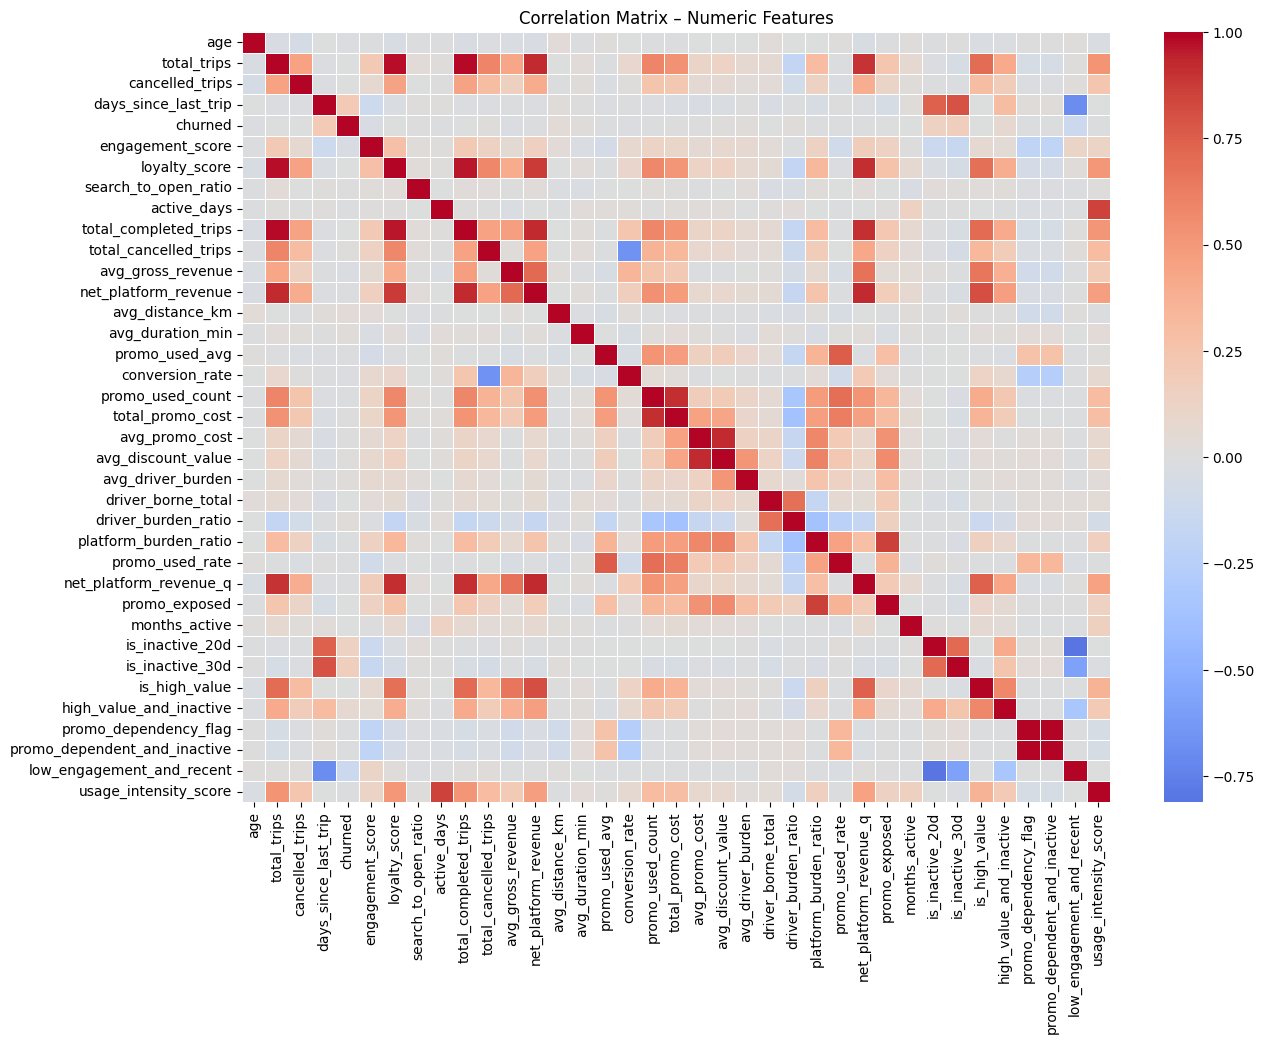

In [70]:
# Reconfirm to further drop features if correlated

# Visualize correlation heatmap
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix – Numeric Features")
plt.show()

In [71]:
# Upper triangle only to avoid duplicates
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "correlation"})
    .query("abs(correlation) >= 0.85")
    .sort_values(by="correlation", key=abs, ascending=False))

high_corr_pairs

,feature_1,feature_2,correlation
660,promo_dependency_flag,promo_dependent_and_inactive,1.000
43,total_trips,total_completed_trips,0.986
40,total_trips,loyalty_score,0.975
203,loyalty_score,total_completed_trips,0.961
290,total_completed_trips,net_platform_revenue,0.929
46,total_trips,net_platform_revenue,0.924
513,avg_promo_cost,avg_discount_value,0.923
379,net_platform_revenue,net_platform_revenue_q,0.918
220,loyalty_score,net_platform_revenue_q,0.914
476,promo_used_count,total_promo_cost,0.909


In [72]:
initial_shape = df.shape

In [73]:
# To drop correlated features again
drop_features_round_2 = ["total_trips", "total_completed_trips", "net_platform_revenue_q",
    "promo_used_count", "avg_promo_cost", "active_days", "promo_exposed", "promo_dependency_flag",
    "promo_dependent_and_inactive"]

df = df.drop(columns=drop_features_round_2)

In [74]:
print("Before:", initial_shape)
print("After:", df.shape)

Before: (3000, 60)
After: (3000, 51)


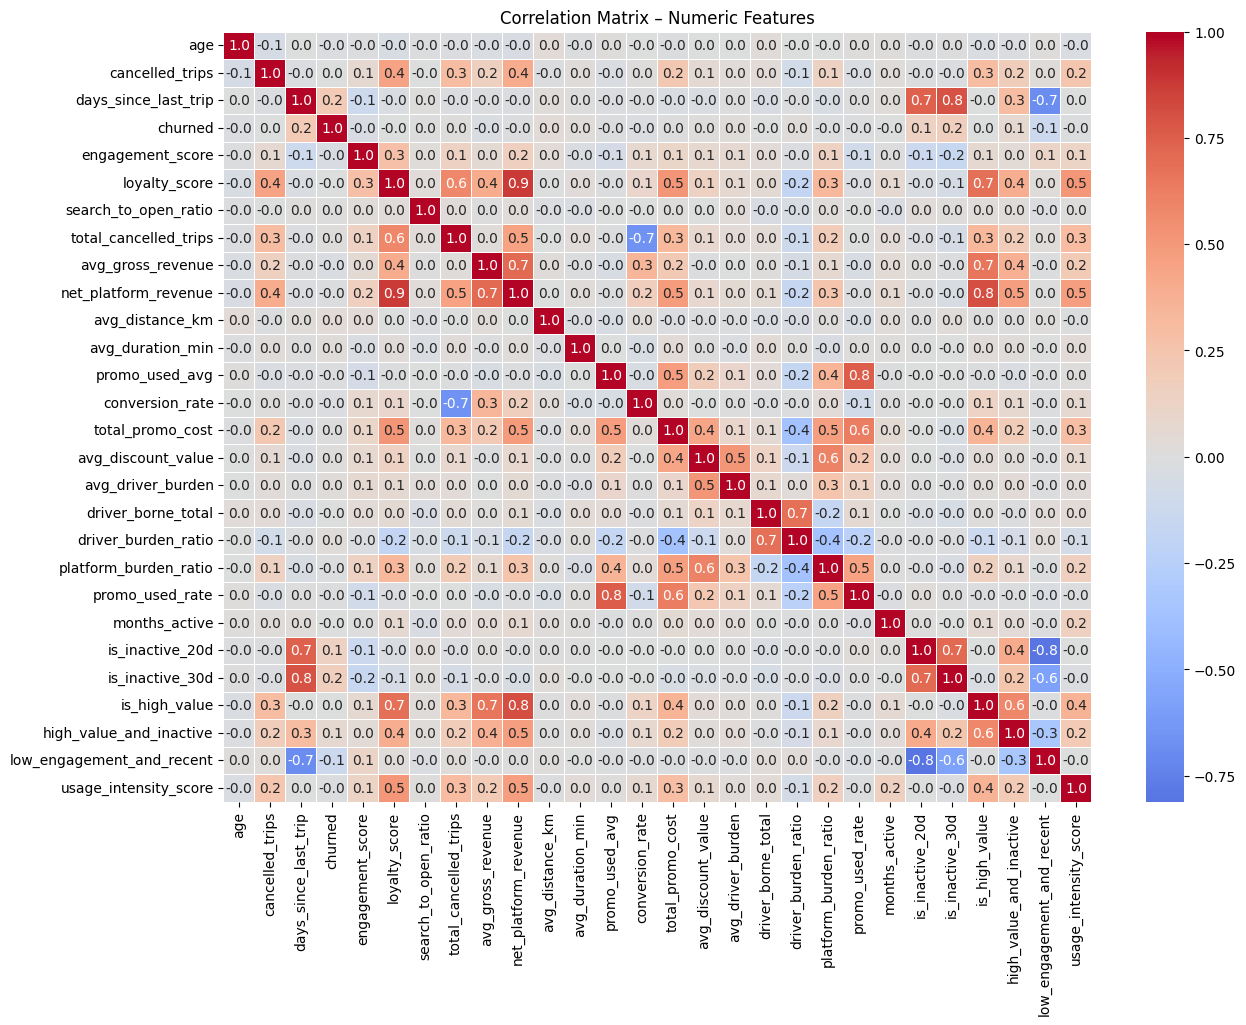

In [75]:
# Visualize correlation heatmap
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, 
            annot=True, fmt='.1f', linewidths=0.5)
plt.title("Correlation Matrix – Numeric Features")
plt.show()

In [76]:
# Compute VIF to show multi-collinearity

X = df.select_dtypes(include=[np.number]).drop(columns=["churned"])

vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                 for i in range(X.shape[1])]

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
3,engagement_score,2216.185
12,conversion_rate,1189.597
4,loyalty_score,1166.091
10,avg_duration_min,179.613
9,avg_distance_km,154.579
7,avg_gross_revenue,135.438
5,search_to_open_ratio,97.015
8,net_platform_revenue,90.431
18,platform_burden_ratio,62.474
6,total_cancelled_trips,36.028


In [77]:
initial_shape = df.shape

In [78]:
# To drop features based on VIF findings
drop_features_vif = ["engagement_score", "loyalty_score", "conversion_rate", 
                     "months_active", "avg_gross_revenue",  "avg_distance_km", 
                     "platform_burden_ratio", "search_to_open_ratio"]

df = df.drop(columns=drop_features_vif)

In [79]:
print("Before:", initial_shape)
print("After:", df.shape)

Before: (3000, 51)
After: (3000, 43)


In [80]:
# VIF for multicolinearity check
X = df.select_dtypes(include=[np.number]).drop(columns=["churned"])

vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                 for i in range(X.shape[1])]

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
5,avg_duration_min,44.579
4,net_platform_revenue,23.578
8,avg_discount_value,16.898
6,promo_used_avg,16.791
18,usage_intensity_score,16.062
12,promo_used_rate,15.538
7,total_promo_cost,13.695
0,age,9.024
13,is_inactive_20d,7.313
2,days_since_last_trip,6.937


In [81]:
# Prepare data for modeling
drop_cols = ["customer_id", "persona", "signup_date", "first_trip_date", "last_trip_date", "last_event_date", "city",
             'first_name', 'last_name', 'email', 'phone']
df = df.drop(columns=drop_cols)

In [82]:
df.columns

Index(['age', 'gender', 'cancelled_trips', 'days_since_last_trip', 'churned',
       'signup_channel', 'income_level', 'payment_method', 'device_type',
       'age_band', 'total_cancelled_trips', 'net_platform_revenue',
       'avg_duration_min', 'promo_used_avg', 'total_promo_cost',
       'avg_discount_value', 'avg_driver_burden', 'driver_borne_total',
       'driver_burden_ratio', 'promo_used_rate', 'promo_dependency',
       'revenue_quartile', 'promo_intensity_q', 'signup_month',
       'last_trip_month', 'is_inactive_20d', 'is_inactive_30d',
       'recency_bucket', 'is_high_value', 'high_value_and_inactive',
       'low_engagement_and_recent', 'usage_intensity_score'],
      dtype='object')

In [83]:
# To save data for feature engineering and segmentation
# df.to_csv('../data/processed/ridewise_cus_seg.csv', index=False)

### Overall Findings

This exploratory analysis examined customer churn through recency, activity, revenue, promotion exposure, and cohort behavior to identify practical early-warning signals and priority retention segments.

Recency emerged as the strongest and most consistent churn driver. Customers who churned had been inactive for substantially longer than those who remained active, with median days since last trip rising from ~13 days (active users) to ~23 days (churned users). Among inactive users (≥20 days since last trip), churned customers showed even longer inactivity (median ~41 days) compared to inactive but retained users (~33 days), confirming that prolonged inactivity sharply increases churn risk.

Revenue alone did not protect against churn. Across total gross revenue, average gross revenue, and net platform revenue, churn rates remained relatively flat across revenue deciles and quartiles. Even top-revenue customers exhibited churn rates comparable to lower-revenue segments. This indicates that value without engagement does not prevent churn.

The most critical risk segment is high-value but inactive customers. When revenue was analyzed jointly with recency, churn increased dramatically for high-revenue customers who became inactive. High-value + inactive customers showed churn rates approaching ~27–31%, far above the overall churn rate (~18%), while high-value customers who remained recent had much lower churn (~10–13%). This confirms that recency overwhelms revenue effects and defines the highest-priority intervention group.

With cancellation and conversion behavior, churned customers consistently showed higher cancellation rates and weaker conversion signals, confirming that churn is preceded by friction in the trip experience, not sudden disengagement.

Promotion usage shows diminishing returns. Moderate promotion intensity (mid-low to mid-high) was associated with higher revenue and activity, but the highest promotion intensity did not produce the strongest revenue outcomes and did not reduce churn meaningfully. Churn rates were actually lowest in the high-promo group, suggesting promotions may stabilize some users, but heavy discounting does not linearly increase revenue and should be applied selectively.

Promotions are associated with slightly better recency but limited churn impact. Promo-exposed users had lower median days since last trip (~15 days) compared to non-exposed users (~18 days), indicating short-term re-engagement effects. However, overall churn rates between promo-exposed and non-exposed users were nearly identical, suggesting promotions alone do not solve churn without sustained engagement.

Usage intensity differentiates recovery vs loss among inactive users. Among inactive users, churned and non-churned customers had similar historical trip counts and active days, implying that past loyalty does not guarantee recovery once inactivity sets in. This reinforces the need for early intervention before users cross inactivity thresholds.

Cohort retention analysis revealed data limitations rather than behavioral signals. Sparse cohort coverage, irregular activity windows, and heavy right-censoring made traditional cohort retention curves unreliable. Lifetime analysis confirmed this: churned and non-churned users had nearly identical median lifetimes (~29 months), indicating churn is driven by recent behavior changes, not total tenure.

**Final Takeaway**

Churn in this dataset is behavior-driven, not value-driven.
The clearest and most actionable insight is:

- High-value customers who become inactive are the highest-risk and highest-impact churn segment.

Effective retention should therefore prioritize early recency-based triggers, supported by targeted (not excessive) promotional nudges, rather than relying on historical spend or loyalty alone.